In [14]:
"""
=============================================================================
  CDO Synthétique - Pricing Monte Carlo
  Modèle : Intensité stochastique bottom-up avec sauts (Affine Jump-Diffusion)
  Indice : CDX NA IG (N=125 noms)
=============================================================================

"""

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# 0. GRAINE ET PARAMÈTRES
# ─────────────────────────────────────────────
rng = np.random.default_rng(seed=42)

# --- Portefeuille ---
N   = 125
R   = 0.40
LGD = 1.0 - R
r   = 0.0014
T   = 5.0

# --- Tranches ---
TRANCHES = [
    (0.00, 0.03),
    (0.03, 0.07),
    (0.07, 0.15),
    (0.15, 1.00),
]
TRANCHE_NAMES = ["Equity [0,3%]", "Mezz I [3,7%]", "Mezz II [7,15%]", "Senior [15,100%]"]

# --- Processus systémique ---
kappa    = 0.6
theta    = 0.02
sigma    = 0.14
lambda_J = 0.05
mu_jump  = 0.10
lam0     = 0.02

# --- Idiosyncratique ---
beta     = 1.0
lam_idio = 0.001

# --- Discrétisation ---
dt      = 1.0 / 252
n_steps = int(T / dt)
M       = 10_000

# --- Dates de paiement ---
pay_dates = np.arange(0.25, T + 1e-10, 0.25)
n_pay = len(pay_dates)

pay_idx = np.round(pay_dates / dt).astype(int) - 1
pay_idx = np.clip(pay_idx, 0, n_steps - 1)

print("=" * 60)
print("  CDO SYNTHÉTIQUE – MONTE CARLO")
print(f"  M={M:,} scénarios | N={N} noms | T={T} ans")
print("=" * 60)

# 1. SIMULATION DU FACTEUR SYSTÉMIQUE
# ─────────────────────────────────────────────

lam_syst = np.full(M, lam0)
int_lam_syst_pay = np.zeros((M, n_pay))
cum_integral = np.zeros(M)

pay_counter = 0


for step in range(n_steps):
    Z = rng.standard_normal(M)

    lam_plus = np.maximum(lam_syst, 0.0)

    n_jumps = rng.poisson(lambda_J * dt, size=M)

    jump_sizes = np.where(
        n_jumps > 0,
        rng.gamma(shape=n_jumps + 1e-10, scale=mu_jump),
        0.0
    )
    jump_sizes = np.where(n_jumps == 0, 0.0, jump_sizes)

    lam_syst = (
        lam_plus
        + kappa * (theta - lam_plus) * dt
        + sigma * np.sqrt(lam_plus * dt) * Z
        + jump_sizes
    )

    lam_syst = np.maximum(lam_syst, 0.0)

    cum_integral += lam_syst * dt

    if pay_counter < n_pay and step == pay_idx[pay_counter]:
        int_lam_syst_pay[:, pay_counter] = cum_integral
        pay_counter += 1

print(f"   λ_syst final moyen: {lam_syst.mean():.5f}")


# 2. INTENSITÉ INTÉGRÉE
# ─────────────────────────────────────────────


idio_contrib = lam_idio * pay_dates
Lambda_total = int_lam_syst_pay + idio_contrib[np.newaxis, :]


# 3. DÉFAUTS
# ─────────────────────────────────────────────


E = rng.exponential(scale=1.0, size=(M, N))

defaulted = Lambda_total[:, :, np.newaxis] > E[:, np.newaxis, :]


# 4. PERTES
# ─────────────────────────────────────────────


n_def = defaulted.sum(axis=2)
L_port = n_def * LGD / N

n_tranches = len(TRANCHES)
ETL = np.zeros((n_tranches, n_pay))

for j, (A, D) in enumerate(TRANCHES):
    width = D - A
    L_tr = (np.minimum(L_port, D) - A).clip(min=0.0) / width
    ETL[j, :] = L_tr.mean(axis=0)


# 5. SPREADS
# ─────────────────────────────────────────────

disc = np.exp(-r * pay_dates)
dt_pay = np.diff(np.concatenate([[0.0], pay_dates]))

ETL_with_0 = np.hstack([np.zeros((n_tranches, 1)), ETL])
dETL = np.diff(ETL_with_0, axis=1)

spreads_bps = []
results = []

for j in range(n_tranches):
    A, D = TRANCHES[j]

    PL = np.sum(disc * dETL[j, :])
    RPL = np.sum(disc * dt_pay * (1.0 - ETL[j, :]))

    s_star = (PL / RPL) * 10_000 if RPL > 1e-12 else np.nan

    spreads_bps.append(s_star)
    results.append({
        "Tranche": TRANCHE_NAMES[j],
        "Spread (bps)": f"{s_star:.2f}",
    })


# 6. RÉSULTATS
# ─────────────────────────────────────────────
df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("  SPREADS PAR TRANCHE")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)

print("\n--- Diagnostics ---")
print(f"Perte moyenne: {L_port[:, -1].mean():.4%}")
print(f"Nb moyen de défauts: {n_def[:, -1].mean():.2f}")
print(f"ETL Equity: {ETL[0, -1]:.4%}")
print(f"ETL Senior: {ETL[3, -1]:.4%}")

  CDO SYNTHÉTIQUE – MONTE CARLO
  M=10,000 scénarios | N=125 noms | T=5.0 ans
   λ_syst final moyen: 0.02802

  SPREADS PAR TRANCHE
         Tranche Spread (bps)
   Equity [0,3%]      6285.66
   Mezz I [3,7%]      1676.46
 Mezz II [7,15%]       396.36
Senior [15,100%]         9.07

--- Diagnostics ---
Perte moyenne: 7.2119%
Nb moyen de défauts: 15.02
ETL Equity: 95.5532%
ETL Senior: 0.4539%


λ (intensité marginale) = 0.006167  (61.67 bps)

  Equity [0,3%]
    Spread cible   :  6285.66 bps
    Intervalle LHP : [54.77, 1786.12] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Mezz I [3,7%]
    Spread cible   :  1676.46 bps
    Intervalle LHP : [0.00, 232.13] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Mezz II [7,15%]
    Spread cible   :   396.36 bps
    Intervalle LHP : [0.00, 110.86] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Senior [15,100%]
    Spread cible   :     9.07 bps
    Intervalle LHP : [0.00, 28.62] bps
    ρ* implicite : 0.6492  (64.92%)

  TABLEAU FINAL – CORRÉLATION IMPLICITE vs FRONTIÈRE DU MODÈLE LHP
         Tranche Spread cible (bps) Min LHP (bps) Max LHP (bps) Dans l’intervalle ?     ρ* implicite
   Equity [0,3%]            6285.66         54.77       1786.12                 Non —  (hors modèle)
   Mezz I [3,7%]            1676.46          0.00        232.13                 Non —  (hors modèle)
 Mezz II [

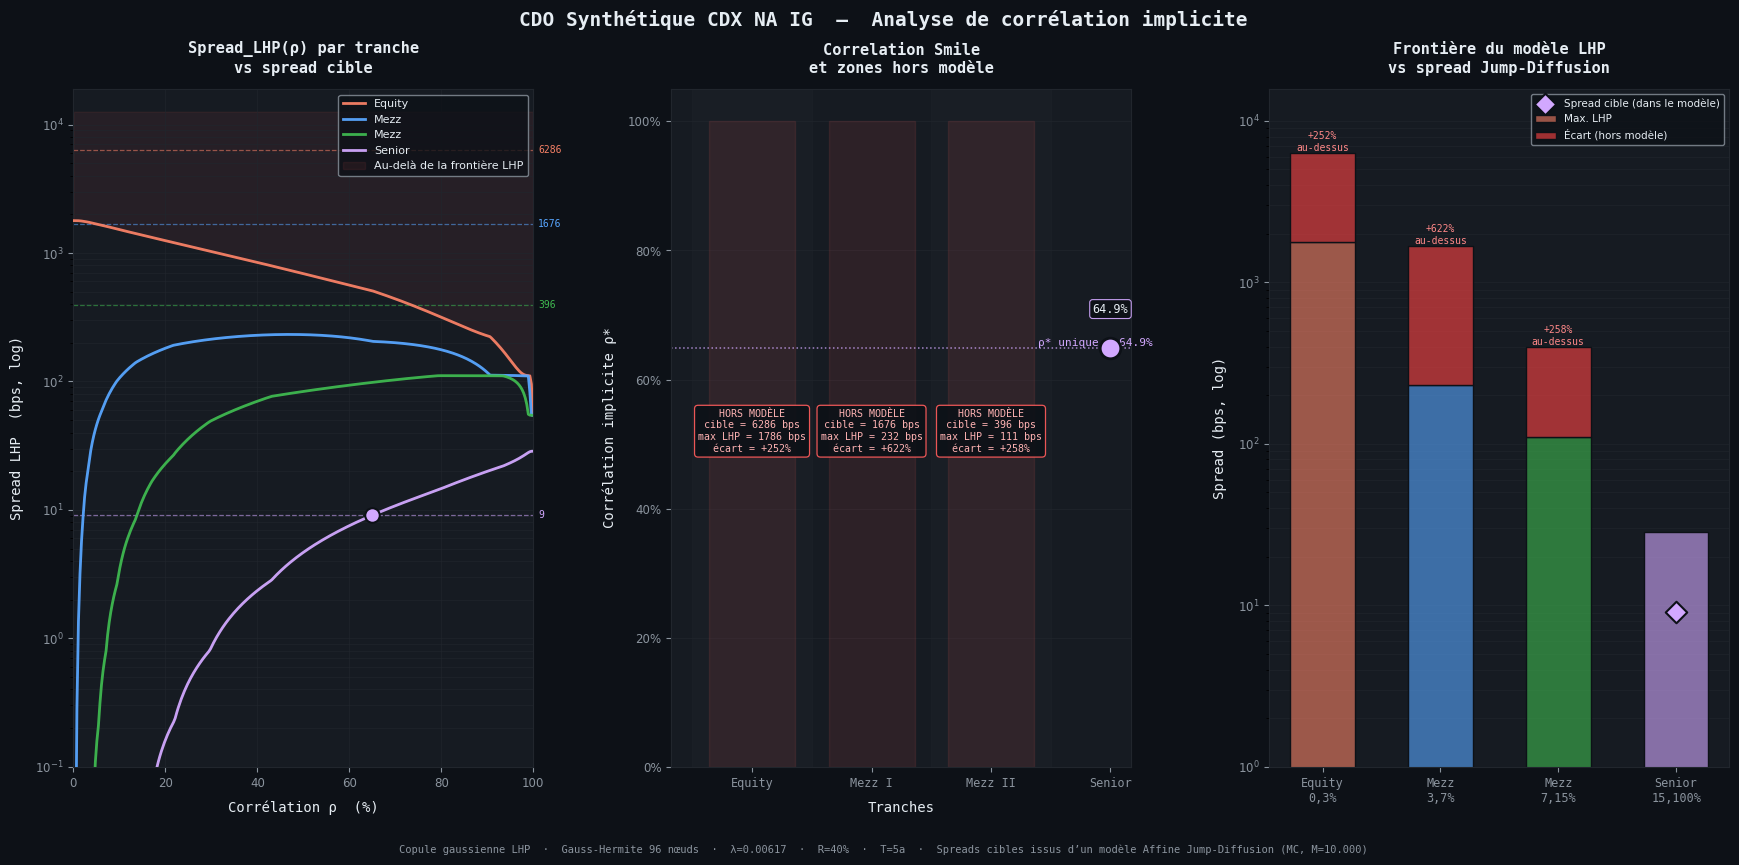

In [13]:
"""
=============================================================================
  CDO SYNTHÉTIQUE – CORRÉLATION IMPLICITE & CORRELATION SMILE
  Modèle : Copule gaussienne + LHP (Large Homogeneous Portfolio)
  Méthode : Compound Correlation + Base Correlation + diagnostic de modèle
=============================================================================
Le script :
  1. calcule les spreads LHP en fonction de ρ ∈ [0,1] pour chaque tranche ;
  2. vérifie si le spread cible appartient au domaine atteignable du modèle ;
  3. calcule la corrélation implicite lorsque cela est possible ;
  4. trace le correlation smile et un diagnostic de modèle.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.special import roots_hermite


# 0. PARAMÈTRES
# ─────────────────────────────────────────────────────────────────
R   = 0.40
LGD = 1.0 - R
r   = 0.0014
T   = 5.0

# λ = spread_indice / LGD  (spread moyen CDX IG ≈ 37 bps)
lam = 0.0037 / LGD
print(f"λ (intensité marginale) = {lam:.6f}  ({lam*10_000:.2f} bps)")

pay_dates = np.arange(0.25, T + 1e-10, 0.25)
disc      = np.exp(-r * pay_dates)
dt_pay    = np.diff(np.concatenate([[0.0], pay_dates]))

TRANCHES       = [(0.00, 0.03), (0.03, 0.07), (0.07, 0.15), (0.15, 1.00)]
TRANCHE_NAMES  = ["Equity [0,3%]", "Mezz I [3,7%]", "Mezz II [7,15%]", "Senior [15,100%]"]
SPREADS_TARGET = np.array([6285.66, 1676.46, 396.36, 9.07])


# 1. QUADRATURE DE GAUSS-HERMITE
# ─────────────────────────────────────────────────────────────────
N_QUAD = 96
x_herm, w_herm = roots_hermite(N_QUAD)
m_nodes = np.sqrt(2.0) * x_herm
w_gauss = w_herm / np.sqrt(np.pi)


# 2. FONCTIONS LHP
# ─────────────────────────────────────────────────────────────────

def etl_tranche(rho, t, A, D):
    """ETL de la tranche [A,D] via quadrature de Gauss-Hermite."""
    p    = 1.0 - np.exp(-lam * t)
    zbar = norm.ppf(p)
    arg  = (zbar - np.sqrt(rho) * m_nodes) / np.sqrt(max(1.0 - rho, 1e-12))
    L    = LGD * norm.cdf(arg)
    width = D - A
    loss  = np.clip(L - A, 0.0, width) / width
    return np.dot(w_gauss, loss)

def spread_lhp(rho, A, D):
    """Spread juste (en bps) de la tranche [A,D] pour une corrélation ρ donnée."""
    etl  = np.array([etl_tranche(rho, t, A, D) for t in pay_dates])
    detl = np.diff(np.concatenate([[0.0], etl]))
    PL   = np.sum(disc * detl)
    RPL  = np.sum(disc * dt_pay * (1.0 - etl))
    return (PL / RPL * 10_000.0) if RPL > 1e-14 else np.nan


# 3. BALAYAGE : SPREAD LHP vs ρ
# ─────────────────────────────────────────────────────────────────

rho_scan = np.linspace(0.001, 0.999, 300)
spread_curves = []
for (A, D) in TRANCHES:
    curve = np.array([spread_lhp(rho, A, D) for rho in rho_scan])
    spread_curves.append(curve)


# 4. CORRÉLATION IMPLICITE (COMPOUND) via BRENTQ
# ─────────────────────────────────────────────────────────────────


implied_rho = []
in_range    = []
s_min_lhp   = []
s_max_lhp   = []

for j, ((A, D), name, s_tgt, curve) in enumerate(
    zip(TRANCHES, TRANCHE_NAMES, SPREADS_TARGET, spread_curves)
):
    s_min = np.nanmin(curve)
    s_max = np.nanmax(curve)
    s_min_lhp.append(s_min)
    s_max_lhp.append(s_max)

    within = (s_min <= s_tgt <= s_max)
    in_range.append(within)

    print(f"\n  {name}")
    print(f"    Spread cible   : {s_tgt:8.2f} bps")
    print(f"    Intervalle LHP : [{s_min:.2f}, {s_max:.2f}] bps")

    if within:
        def f_obj(rho, A=A, D=D, s=s_tgt):
            return spread_lhp(rho, A, D) - s

        f_scan = curve - s_tgt
        cidxs = np.where(np.diff(np.sign(f_scan)))[0]

        rho_star = brentq(
            f_obj,
            rho_scan[cidxs[0]],
            rho_scan[cidxs[0] + 1],
            xtol=1e-8,
            maxiter=300
        )
        print(f"    ρ* implicite : {rho_star:.4f}  ({rho_star*100:.2f}%)")
    else:
        rho_star = np.nan
        direction = "AU-DESSUS" if s_tgt > s_max else "EN DESSOUS"
        print(f"   Hors frontière LHP ({direction}) — pas de ρ implicite")

    implied_rho.append(rho_star)


# 5. TABLEAU DE RÉSULTATS
# ─────────────────────────────────────────────────────────────────
df = pd.DataFrame({
    "Tranche"             : TRANCHE_NAMES,
    "Spread cible (bps)"  : [f"{s:.2f}" for s in SPREADS_TARGET],
    "Min LHP (bps)"       : [f"{s:.2f}" for s in s_min_lhp],
    "Max LHP (bps)"       : [f"{s:.2f}" for s in s_max_lhp],
    "Dans l’intervalle ?" : ["Oui" if v else " Non" for v in in_range],
    "ρ* implicite"        : [
        f"{rho:.4f}  ({rho*100:.1f}%)" if not np.isnan(rho)
        else "—  (hors modèle)"
        for rho in implied_rho
    ],
})

print("\n" + "=" * 90)
print("  TABLEAU FINAL – CORRÉLATION IMPLICITE vs FRONTIÈRE DU MODÈLE LHP")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)



# 6. GRAPHIQUE
# ─────────────────────────────────────────────────────────────────


BG_DARK  = "#0D1117"
BG_PANEL = "#161B22"
GRID_COL = "#21262D"
TEXT_COL = "#E6EDF3"
MUTED    = "#8B949E"
RED_WARN = "#FF5C5C"
COLORS   = ["#F78166", "#58A6FF", "#3FB950", "#D2A8FF"]

fig = plt.figure(figsize=(18, 8.8), facecolor=BG_DARK)
gs  = fig.add_gridspec(
    1, 3,
    left=0.05, right=0.97,
    top=0.88, bottom=0.11,
    wspace=0.30
)

# ── Painel A : Spread_LHP(ρ) por tranche ────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG_PANEL)

for j, ((A, D), name, curve, s_tgt, color) in enumerate(
    zip(TRANCHES, TRANCHE_NAMES, spread_curves, SPREADS_TARGET, COLORS)
):
    ax1.semilogy(
        rho_scan * 100,
        curve,
        color=color,
        lw=2.0,
        label=f"{name.split(' ')[0]}",
        alpha=0.95,
        zorder=3
    )

    ax1.axhline(s_tgt, color=color, lw=0.9, ls="--", alpha=0.55)

    ax1.text(
        101, s_tgt, f"{s_tgt:.0f}",
        va="center", ha="left",
        fontsize=7, color=color, fontfamily="monospace"
    )

    if not np.isnan(implied_rho[j]):
        ax1.scatter(
            [implied_rho[j] * 100], [s_tgt],
            s=110, color=color, zorder=6,
            edgecolors=BG_DARK, linewidths=1.5
        )

max_curve = np.max([curve for curve in spread_curves], axis=0)
ax1.fill_between(
    rho_scan * 100,
    max_curve,
    np.full_like(rho_scan, max(SPREADS_TARGET) * 2),
    alpha=0.07, color=RED_WARN,
    label="Au-delà de la frontière LHP"
)

ax1.set_xlabel(
    "Corrélation ρ  (%)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax1.set_ylabel(
    "Spread LHP  (bps, log)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax1.set_title(
    "Spread_LHP(ρ) par tranche\nvs spread cible",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax1.set_xlim(0, 100)
ax1.set_ylim(0.1, max(SPREADS_TARGET) * 3)
ax1.tick_params(colors=MUTED, labelsize=8.5)
ax1.spines[:].set_color(GRID_COL)
ax1.grid(True, color=GRID_COL, lw=0.6, alpha=0.75, which="both")
ax1.legend(
    fontsize=8,
    facecolor=BG_DARK,
    edgecolor=MUTED,
    labelcolor=TEXT_COL,
    loc="upper right"
)

# ── Painel B : Correlation Smile (versão melhorada) ─────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG_PANEL)

x_pos = np.arange(len(TRANCHES))
rho_pct = np.array(implied_rho) * 100.0
valid = ~np.isnan(rho_pct)

# Fundo alternado por tranche para leitura
for j in range(len(TRANCHES)):
    if j % 2 == 0:
        ax2.axvspan(j - 0.5, j + 0.5, color="#FFFFFF", alpha=0.015, zorder=0)

# Linha-guia horizontal
for y in [0, 20, 40, 60, 80, 100]:
    ax2.axhline(y, color=GRID_COL, lw=0.7, alpha=0.7, zorder=0)

# Colunas de fundo para "hors modèle"
for j in range(len(TRANCHES)):
    if not valid[j]:
        ax2.bar(
            x_pos[j], 100,
            width=0.72,
            color=RED_WARN,
            alpha=0.10,
            edgecolor=RED_WARN,
            linewidth=1.0,
            zorder=1
        )

        gap_pct_j = (SPREADS_TARGET[j] / s_max_lhp[j] - 1.0) * 100.0 if s_max_lhp[j] > 0 else np.nan
        txt = (
            "HORS MODÈLE\n"
            f"cible = {SPREADS_TARGET[j]:.0f} bps\n"
            f"max LHP = {s_max_lhp[j]:.0f} bps"
        )
        if np.isfinite(gap_pct_j):
            txt += f"\nécart = +{gap_pct_j:.0f}%"

        ax2.text(
            x_pos[j], 52, txt,
            ha="center", va="center",
            fontsize=7.2, color="#FFB3B3",
            fontfamily="monospace",
            bbox=dict(
                boxstyle="round,pad=0.35",
                fc=BG_DARK, ec=RED_WARN, alpha=0.92, lw=0.9
            ),
            zorder=4
        )

# Linha ligando apenas os pontos válidos
if valid.sum() >= 2:
    ax2.plot(
        x_pos[valid], rho_pct[valid],
        color="#58A6FF", lw=1.8, ls="--", alpha=0.8, zorder=3
    )

# Pontos válidos
for j in range(len(TRANCHES)):
    if valid[j]:
        ax2.scatter(
            x_pos[j], rho_pct[j],
            s=220, color=COLORS[j],
            edgecolors=BG_DARK, linewidths=2.0,
            zorder=5
        )
        ax2.text(
            x_pos[j], rho_pct[j] + 5.0,
            f"{rho_pct[j]:.1f}%",
            ha="center", va="bottom",
            fontsize=8.5, color=TEXT_COL,
            fontfamily="monospace",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc=BG_DARK, ec=COLORS[j], alpha=0.92, lw=0.8
            ),
            zorder=6
        )

# Se só houver 1 ponto válido, destacar melhor
if valid.sum() == 1:
    j = np.where(valid)[0][0]
    ax2.axhline(rho_pct[j], color=COLORS[j], lw=1.1, ls=":", alpha=0.75, zorder=2)
    ax2.text(
        3.35, rho_pct[j],
        f"ρ* unique = {rho_pct[j]:.1f}%",
        ha="right", va="bottom",
        fontsize=8, color=COLORS[j],
        fontfamily="monospace"
    )

ax2.set_xticks(x_pos)
ax2.set_xticklabels(
    ["Equity", "Mezz I", "Mezz II", "Senior"],
    fontsize=8.5, color=MUTED, fontfamily="monospace"
)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.set_ylabel(
    "Corrélation implicite ρ*",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax2.set_xlabel(
    "Tranches",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax2.set_title(
    "Correlation Smile\net zones hors modèle",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax2.tick_params(colors=MUTED, labelsize=8.5)
ax2.spines[:].set_color(GRID_COL)
ax2.grid(False)

# ── Painel C : Diagnostic — écart du modèle ─────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(BG_PANEL)

labels = [
    n.split(" ")[0] + "\n" + n.split("[")[1].rstrip("]")
    for n in TRANCHE_NAMES
]
x_pos_c   = np.arange(4)
s_max_arr = np.array(s_max_lhp)
s_tgt_arr = SPREADS_TARGET
gap       = s_tgt_arr - s_max_arr
gap_pct   = gap / s_max_arr * 100

ax3.bar(
    x_pos_c, s_max_arr,
    color=[c + "99" for c in COLORS],
    width=0.55,
    label="Max. LHP",
    edgecolor=BG_DARK,
    zorder=2
)

for j in range(4):
    if gap[j] > 0:
        ax3.bar(
            x_pos_c[j], gap[j],
            bottom=s_max_arr[j],
            color="#FF444499",
            width=0.55,
            edgecolor=BG_DARK,
            zorder=3,
            label="Écart (hors modèle)" if j == 0 else ""
        )
        ax3.text(
            x_pos_c[j], s_tgt_arr[j] + s_max_arr[j] * 0.03,
            f"+{gap_pct[j]:.0f}%\nau-dessus",
            ha="center", va="bottom",
            fontsize=7, color="#FF8888",
            fontfamily="monospace"
        )
    else:
        ax3.scatter(
            [x_pos_c[j]], [s_tgt_arr[j]],
            s=120, color=COLORS[j],
            zorder=6, edgecolors=BG_DARK, linewidths=1.5,
            marker="D",
            label="Spread cible (dans le modèle)" if j == 3 else ""
        )

ax3.set_xticks(x_pos_c)
ax3.set_xticklabels(labels, fontsize=7.5, color=MUTED, fontfamily="monospace")
ax3.set_ylabel(
    "Spread (bps, log)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax3.set_title(
    "Frontière du modèle LHP\nvs spread Jump-Diffusion",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax3.set_yscale("log")
ax3.set_ylim(1, max(SPREADS_TARGET) * 2.5)
ax3.tick_params(colors=MUTED, labelsize=8.5)
ax3.spines[:].set_color(GRID_COL)
ax3.grid(True, axis="y", color=GRID_COL, lw=0.6, alpha=0.75, which="both")
ax3.legend(
    fontsize=7.5,
    facecolor=BG_DARK,
    edgecolor=MUTED,
    labelcolor=TEXT_COL,
    loc="upper right"
)

# Bas de figure
fig.text(
    0.5, 0.012,
    f"Copule gaussienne LHP  ·  Gauss-Hermite {N_QUAD} nœuds  ·  "
    f"λ={lam:.5f}  ·  R={R:.0%}  ·  T={T:.0f}a  ·  "
    "Spreads cibles issus d’un modèle Affine Jump-Diffusion (MC, M=10.000)",
    ha="center",
    fontsize=7.5,
    color=MUTED,
    fontfamily="monospace"
)

fig.suptitle(
    "CDO Synthétique CDX NA IG  —  Analyse de corrélation implicite",
    fontsize=14,
    color=TEXT_COL,
    fontweight="bold",
    fontfamily="monospace",
    y=0.97
)

plt.show()

In [1]:
"""
================================================================================
CDO SYNTHÉTIQUE - CALIBRATION MODÈLE AFFINE JUMP-DIFFUSION (Mortensen 2006)
vs COPULE GAUSSIENNE LHP
================================================================================

Méthodologie :
  - Intensités stochastiques : λ_i(t) = λ_idio + β * λ_syst(t)
  - λ_syst(t) suit un processus AJD (Duffie-Gârleanu)
  - Contrainte CDS : E[λ_i] = s_CDS / LGD
    => λ_idio = s_CDS / LGD - β * E[λ_syst]
  - Calibration par grille sur β, minimisation du RMSE_log sur 4 tranches

Références :
  - Mortensen (2006), "Semi-Analytical Valuation of Basket Credit Derivatives"
  - Duffie & Gârleanu (2001), "Risk and Valuation of CDOs"
================================================================================
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
from dataclasses import dataclass
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PARAMÈTRES GLOBAUX (macros)
# ============================================================

# Paramètres du portefeuille
PORTFOLIO = dict(
    N          = 125,       # nombre d'entités
    R          = 0.40,      # taux de recouvrement
    LGD        = 0.60,      # loss given default = 1 - R
    r          = 0.0014,    # taux sans risque constant
    T          = 5.0,       # maturité en années
    freq       = 4,         # paiements trimestriels (par an)
)

# Paramètres structurels du processus AJD pour λ_syst(t)
# dλ_syst = κ(θ - λ_syst) dt + σ√λ_syst dW + dJ
# J : sauts exponentiels d'intensité μ_J, arrivant à taux ξ
AJD_PARAMS = dict(
    kappa  = 0.50,    # vitesse de retour à la moyenne
    theta  = 0.02,    # niveau long terme (E[λ_syst] en régime stationnaire)
    sigma  = 0.10,    # volatilité de diffusion
    xi     = 0.10,    # intensité d'arrivée des sauts (taux de Poisson)
    mu_J   = 0.05,    # taille moyenne des sauts (distribution exponentielle)
    lambda0 = 0.02,   # valeur initiale du processus λ_syst(0)
)

# Paramètres Monte Carlo
MC_PARAMS = dict(
    M     = 5000,   # nombre de trajectoires
    dt    = 1/52,   # pas de temps hebdomadaire (approximation discrète)
    seed  = 42,
)

# Grille de calibration pour β
BETA_GRID = np.linspace(0.01, 2.0, 80)

# Définition des tranches CDX NA IG Series 19 (5 ans)
TRANCHES = [
    dict(name="Equity",  K_lo=0.00, K_hi=0.03),
    dict(name="Mezz1",   K_lo=0.03, K_hi=0.07),
    dict(name="Mezz2",   K_lo=0.07, K_hi=0.15),
    dict(name="Senior",  K_lo=0.15, K_hi=1.00),
]

# Données de marché CDX NA IG S19, T=5 ans
# Equity : upfront en % (running = 500 bps); autres tranches : spread en bps
MARKET_DATA = pd.DataFrame([
    ("2014-06-01", 0.4250, 200.0, 3.6, 1.4, 39),
    ("2014-07-03", 0.3750, 137.5, 4.8, 1.5, 37),
    ("2014-08-15", 0.4094, 171.9, 5.0, 1.4, 38),
    ("2014-09-23", 0.3750, 137.5, 5.6, 1.2, 37),
    ("2014-10-11", 0.5775, 181.0, 5.0, 1.2, 41),
    ("2014-11-17", 0.4188,  98.5, 5.7, 1.5, 35),
    ("2014-12-01", 0.3183,  74.7, 6.0, 1.6, 32),
    ("2015-01-07", 0.7065,  87.5, 5.5, 1.3, 39),
    ("2015-02-10", 0.7559,  56.3, 5.5, 1.4, 37),
    ("2015-03-15", 0.6874,   7.3, 6.4, 1.5, 34),
], columns=["date", "equity_upfront", "mezz1_bps", "mezz2_bps", "senior_bps", "cds_bps"])

MARKET_DATA["date"] = pd.to_datetime(MARKET_DATA["date"])


# ============================================================
# SECTION 1 : PROPRIÉTÉS ANALYTIQUES DU PROCESSUS AJD
# ============================================================

def ajd_mean_stationary(params: dict) -> float:
    """
    Calcule E[λ_syst] en régime stationnaire.

    Pour un processus AJD de type CIR + sauts exponentiels :
        dλ = κ(θ - λ) dt + σ√λ dW + dJ,  J ~ Exp(1/μ_J)

    L'espérance stationnaire est :
        E[λ_syst] = θ + ξ * μ_J / κ

    où :
        θ     : niveau de retour à la moyenne du drift
        ξ     : intensité de Poisson des sauts
        μ_J   : taille moyenne d'un saut
        κ     : vitesse de retour à la moyenne
    """
    kappa = params['kappa']
    theta = params['theta']
    xi    = params['xi']
    mu_J  = params['mu_J']
    return theta + xi * mu_J / kappa


def ajd_mean_integrated(params: dict, T: float) -> float:
    """
    Calcule E[∫_0^T λ_syst(t) dt] analytiquement via la fonction de Laplace AJD.

    Pour un processus AJD partant de λ_0 :
        E[∫_0^T λ dt] = A(T) + B(T) * λ_0

    où A(T) et B(T) sont les fonctions affines de la transform de Laplace :
        E[exp(-s ∫ λ dt)] = exp(A(T,s) + B(T,s)*λ_0)

    En différenciant par rapport à s en s=0 :
        B(T) = ∫_0^T e^{-κt} dt = (1 - e^{-κT}) / κ
        A(T) = (θ + ξ μ_J / κ) * (T - B(T))

    C'est la formule standard du modèle CIR étendu (cf. Duffie-Pan-Singleton 2000).
    """
    kappa  = params['kappa']
    theta  = params['theta']
    xi     = params['xi']
    mu_J   = params['mu_J']
    lambda0 = params['lambda0']

    # Contribution du terme de diffusion (type CIR)
    B_T = (1.0 - np.exp(-kappa * T)) / kappa

    # Niveau effectif incluant la contribution moyenne des sauts
    theta_eff = theta + xi * mu_J / kappa

    A_T = theta_eff * (T - B_T)

    return A_T + B_T * lambda0


# ============================================================
# SECTION 2 : SIMULATION MONTE CARLO DU MODÈLE AJD
# ============================================================

def simulate_ajd_paths(params: dict, T: float, dt: float, M: int,
                        seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simule M trajectoires du processus λ_syst(t) par schéma d'Euler-Maruyama
    avec traitement explicite des sauts de Poisson.

    Schéma de discrétisation :
        λ_{t+dt} = λ_t + κ(θ - λ_t) dt + σ√(max(λ_t,0)) √dt * Z + J_t
    où :
        Z ~ N(0,1)
        J_t ~ somme de Exp(1/μ_J), nombre de sauts ~ Poisson(ξ * dt)

    Retourne :
        paths     : array (M, n_steps+1) des trajectoires λ_syst
        time_grid : array (n_steps+1,) de la grille temporelle
    """
    rng = np.random.default_rng(seed)

    kappa  = params['kappa']
    theta  = params['theta']
    sigma  = params['sigma']
    xi     = params['xi']
    mu_J   = params['mu_J']
    lambda0 = params['lambda0']

    n_steps = int(np.round(T / dt))
    time_grid = np.linspace(0.0, T, n_steps + 1)

    # Initialisation : toutes les trajectoires démarrent à lambda0
    paths = np.zeros((M, n_steps + 1))
    paths[:, 0] = lambda0

    sqrt_dt = np.sqrt(dt)

    for t_idx in range(n_steps):
        lam = paths[:, t_idx]
        lam_pos = np.maximum(lam, 0.0)  # floor à 0 pour la racine carrée

        # Partie diffusion (Wiener)
        Z = rng.standard_normal(M)
        drift = kappa * (theta - lam) * dt
        diffusion = sigma * np.sqrt(lam_pos) * sqrt_dt * Z

        # Partie sauts : nombre de sauts ~ Poisson(ξ dt) par trajectoire
        n_jumps = rng.poisson(xi * dt, size=M)
        # Taille totale des sauts : somme de n_jumps variables Exp(1/mu_J)
        # E[J_total | n_jumps=k] = k * mu_J
        # On génère les sauts avec vectorisation (max n_jumps typique est petit)
        jump_sizes = np.zeros(M)
        max_jumps = int(n_jumps.max()) if n_jumps.max() > 0 else 0
        for k in range(1, max_jumps + 1):
            mask = n_jumps >= k
            jump_sizes[mask] += rng.exponential(mu_J, size=mask.sum())

        paths[:, t_idx + 1] = np.maximum(lam + drift + diffusion + jump_sizes, 0.0)

    return paths, time_grid


def compute_integrated_intensity(paths: np.ndarray, time_grid: np.ndarray,
                                  beta: float, lambda_idio: float) -> np.ndarray:
    """
    Calcule ∫_0^T λ_i(t) dt = λ_idio * T + β * ∫_0^T λ_syst(t) dt
    pour chaque trajectoire Monte Carlo.

    Utilise la règle des trapèzes pour l'intégrale numérique.

    Paramètres :
        paths       : (M, n_steps+1) trajectoires de λ_syst
        time_grid   : (n_steps+1,) grille temporelle
        beta        : chargement systémique
        lambda_idio : intensité idiosyncratique

    Retourne :
        integrated : (M,) vecteur des intensités intégrées par trajectoire
    """
    dt = np.diff(time_grid)
    # Intégrale trapèzes de λ_syst : (M,)
    integral_syst = np.sum(0.5 * (paths[:, :-1] + paths[:, 1:]) * dt[np.newaxis, :], axis=1)
    integrated = lambda_idio * time_grid[-1] + beta * integral_syst
    return integrated


# ============================================================
# SECTION 3 : PRICING DES TRANCHES CDO
# ============================================================

def compute_loss_distribution(integrated_intensity: np.ndarray,
                               N: int, LGD: float,
                               seed: int = 123) -> np.ndarray:
    """
    Calcule la distribution de perte du portefeuille à maturité T.

    Pour chaque trajectoire m et chaque entité i :
        P(défaut_i | trajectoire m) = 1 - exp(-Λ_i^m)
    où Λ_i^m = ∫_0^T λ_i(t) dt est l'intensité intégrée.

    Sous hypothèse d'indépendance conditionnelle (doubly-stochastic) :
        - Générer U_i ~ Uniforme(0,1)
        - Défaut si U_i < 1 - exp(-Λ_i^m)

    Perte normalisée : L = LGD * (nb_défauts) / N

    VECTORISATION : on traite toutes les trajectoires et entités en un seul bloc.
    """
    M = len(integrated_intensity)
    rng = np.random.default_rng(seed)

    # P(défaut) par trajectoire (identique pour toutes les entités car portefeuille homogène)
    p_default = 1.0 - np.exp(-integrated_intensity)  # shape (M,)

    # Tirage uniforme pour N entités × M trajectoires
    U = rng.uniform(0, 1, size=(M, N))  # shape (M, N)

    # Comparaison : défaut si U < p_default (broadcast sur N entités)
    defaults = U < p_default[:, np.newaxis]  # (M, N)

    # Nombre de défauts par trajectoire
    n_defaults = defaults.sum(axis=1)  # (M,)

    # Perte normalisée
    loss = LGD * n_defaults / N  # (M,)
    return loss


def tranche_loss(portfolio_loss: np.ndarray, K_lo: float, K_hi: float) -> np.ndarray:
    """
    Calcule la perte de la tranche [K_lo, K_hi] pour chaque scénario.

    Perte tranche = min(max(L - K_lo, 0), K_hi - K_lo) / (K_hi - K_lo)
    (normalisée par l'épaisseur de la tranche)
    """
    width = K_hi - K_lo
    raw = np.clip(portfolio_loss - K_lo, 0.0, width)
    return raw / width


def price_tranche_ajd(loss_at_maturity: np.ndarray,
                       K_lo: float, K_hi: float,
                       r: float, T: float, freq: int,
                       is_equity: bool = False) -> float:
    """
    Calcule le spread (ou upfront) d'une tranche CDO par Monte Carlo.

    Architecture de paiement standard :
    - Protection Leg : E[perte tranche] * facteur d'actualisation
    - Premium Leg    : somme des paiements de primes (risky annuity)

    Pour simplifier (modèle de perte terminale), on assume que la perte
    survient uniformément — approximation valide pour calibration rapide.

    Protection Leg :
        PV_prot = E[L_tranche(T)] * exp(-r*T)

    Premium Leg (running spread s, paiements trimestriels) :
        PV_prem = s * Σ_{k=1}^{n} Δt * exp(-r*t_k) * (1 - E[L_tranche(t_k)])

    Approximation : E[L_tranche(t_k)] ≈ E[L_tranche(T)] * (t_k/T) (interpolation linéaire)

    Pour la tranche Equity (running = 500 bps fixe) :
        Upfront = PV_prot - 0.05 * PV_prem_risky

    Retourne spread en bps ou upfront en fraction (equity).
    """
    n_steps = int(T * freq)
    dt_pay = T / n_steps
    times = np.arange(1, n_steps + 1) * dt_pay  # (n_steps,)

    # Perte terminale de la tranche
    tl = tranche_loss(loss_at_maturity, K_lo, K_hi)  # (M,)
    E_loss_T = tl.mean()

    # Protection Leg
    PV_prot = E_loss_T * np.exp(-r * T)

    # Premium Leg : E[1 - L_tranche(t_k)] ≈ 1 - E_loss_T * (t/T)
    survival_frac = 1.0 - E_loss_T * (times / T)
    discount = np.exp(-r * times)
    annuity = np.sum(discount * survival_frac) * dt_pay  # risky annuity

    if is_equity:
        # Convention equity : upfront + running 500 bps
        running = 0.05  # 500 bps = 5%
        upfront = PV_prot - running * annuity
        return upfront
    else:
        if annuity < 1e-12:
            return 0.0
        spread_bps = (PV_prot / annuity) * 10000  # conversion en bps
        return spread_bps


# ============================================================
# SECTION 4 : COPULE GAUSSIENNE LHP (Large Homogeneous Portfolio)
# ============================================================

def lhp_default_prob(s_cds: float, LGD: float, r: float, T: float) -> float:
    """
    Probabilité de défaut implicite du CDS sous LHP.
    Approximation : P(défaut) = 1 - exp(-s_cds * T / LGD)
    """
    hazard = s_cds / LGD
    return 1.0 - np.exp(-hazard * T)


def gaussian_copula_lhp_tranche(rho: float, p: float,
                                  K_lo: float, K_hi: float,
                                  LGD: float) -> float:
    """
    Calcule E[L_tranche] pour la copule gaussienne LHP.

    Sous LHP avec corrélation ρ, la perte conditionnelle au facteur M est :
        L(m) = LGD * Φ((Φ^{-1}(p) - √ρ * m) / √(1-ρ))

    E[L_tranche] = ∫ min(max(L(m) - K_lo, 0), K_hi-K_lo)/(K_hi-K_lo) φ(m) dm

    Intégration numérique par quadrature de Gauss-Hermite.
    """
    from numpy.polynomial.hermite import hermgauss
    n_quad = 80
    nodes, weights = hermgauss(n_quad)
    # Changement de variable : m = √2 * x
    m_vals = nodes * np.sqrt(2.0)
    w_vals = weights / np.sqrt(np.pi)

    phi_inv_p = norm.ppf(p)
    sqrt_rho = np.sqrt(rho)
    sqrt_1mrho = np.sqrt(1.0 - rho)

    # Perte conditionnelle normalisée L(m)/LGD = fraction de défauts conditionnels
    arg = (phi_inv_p - sqrt_rho * m_vals) / sqrt_1mrho
    # Clip les arguments extrêmes pour éviter les valeurs numériques dégénérées
    arg = np.clip(arg, -8, 8)
    frac_defaults = norm.cdf(arg)           # proportion de défauts conditionnels
    port_loss = LGD * frac_defaults         # perte normalisée du portefeuille

    width = K_hi - K_lo
    tl = np.clip(port_loss - K_lo, 0.0, width) / width  # perte tranche

    return np.dot(tl, w_vals)


def price_tranche_lhp(rho: float, p: float, K_lo: float, K_hi: float,
                       LGD: float, r: float, T: float, freq: int,
                       is_equity: bool = False) -> float:
    """
    Prix d'une tranche CDO sous copule gaussienne LHP.
    Même structure de paiement que le modèle AJD.
    """
    n_steps = int(T * freq)
    dt_pay = T / n_steps
    times = np.arange(1, n_steps + 1) * dt_pay

    # Approximation : E[L_tranche(t)] ≈ E[L_tranche(T)] * (t/T)
    E_loss_T = gaussian_copula_lhp_tranche(rho, p, K_lo, K_hi, LGD)
    PV_prot = E_loss_T * np.exp(-r * T)

    survival_frac = 1.0 - E_loss_T * (times / T)
    discount = np.exp(-r * times)
    annuity = np.sum(discount * survival_frac) * dt_pay

    if is_equity:
        running = 0.05
        upfront = PV_prot - running * annuity
        return upfront
    else:
        if annuity < 1e-12:
            return 0.0
        return (PV_prot / annuity) * 10000


def calibrate_lhp(market_spreads: dict, p: float,
                   LGD: float, r: float, T: float, freq: int) -> Tuple[float, float]:
    """
    Calibre la corrélation ρ de la copule gaussienne LHP par recherche sur grille.

    market_spreads : dict avec keys 'equity_upfront', 'mezz1', 'mezz2', 'senior' (bps)
    Retourne : (rho_optimal, rmse_log)
    """
    rho_grid = np.linspace(0.01, 0.99, 99)
    best_rho = None
    best_rmse = np.inf

    S_mkt = [
        market_spreads['equity_upfront'],
        market_spreads['mezz1_bps'] / 10000,
        market_spreads['mezz2_bps'] / 10000,
        market_spreads['senior_bps'] / 10000,
    ]

    for rho in rho_grid:
        try:
            spreads_model = []
            for i, tr in enumerate(TRANCHES):
                is_eq = (i == 0)
                val = price_tranche_lhp(rho, p, tr['K_lo'], tr['K_hi'],
                                         LGD, r, T, freq, is_equity=is_eq)
                if is_eq:
                    spreads_model.append(val)
                else:
                    spreads_model.append(val / 10000)

            # RMSE_log (equity comparé en upfront, autres en fraction)
            log_errors = []
            for s_m, s_mkt in zip(spreads_model, S_mkt):
                if s_m > 1e-10 and s_mkt > 1e-10:
                    log_errors.append((np.log(s_m / s_mkt)) ** 2)

            if log_errors:
                rmse = np.sqrt(np.mean(log_errors))
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_rho = rho
        except Exception:
            continue

    return best_rho, best_rmse


# ============================================================
# SECTION 5 : FONCTION DE COÛT (RMSE LOG)
# ============================================================

def rmse_log(spreads_model: List[float], market_row: pd.Series) -> float:
    """
    Calcule le RMSE logarithmique entre modèle et marché sur 4 tranches.

    Formule :
        RMSE_log = sqrt(1/4 * Σ_k (ln(S_model_k / S_market_k))^2)

    Convention :
        - Equity    : comparer upfront vs upfront (fraction)
        - Autres    : comparer bps vs bps

    Si une des valeurs est nulle ou négative → on pénalise fortement.
    """
    S_mkt = [
        market_row['equity_upfront'],           # fraction
        market_row['mezz1_bps'] * 1e-4,         # bps → fraction
        market_row['mezz2_bps'] * 1e-4,
        market_row['senior_bps'] * 1e-4,
    ]

    log_sq = []
    for s_m, s_k in zip(spreads_model, S_mkt):
        if s_m > 1e-8 and s_k > 1e-8:
            log_sq.append((np.log(s_m / s_k)) ** 2)
        else:
            log_sq.append(25.0)  # pénalité forte si spread nul ou négatif

    return np.sqrt(np.mean(log_sq))


# ============================================================
# SECTION 6 : CALIBRATION PRINCIPALE (GRILLE SUR β)
# ============================================================

def calibrate_single_date(market_row: pd.Series,
                            ajd_params: dict,
                            portfolio: dict,
                            mc_params: dict,
                            beta_grid: np.ndarray) -> dict:
    """
    Calibre le modèle AJD pour une date de marché donnée.

    Algorithme :
    1. Calculer E[λ_syst] analytiquement (régime stationnaire AJD)
    2. Pour chaque β dans beta_grid :
       a. Déduire λ_idio = s_CDS/LGD - β * E[λ_syst]
          (contrainte : E[λ_i] = s_CDS/LGD pour pricer parfaitement le CDS)
       b. Rejeter si λ_idio < 0
       c. Simuler M trajectoires AJD → calculer intensité intégrée
       d. Calculer distribution de perte
       e. Pricer les 4 tranches
       f. Calculer RMSE_log
    3. Retourner (β*, λ_idio*, RMSE_min, spreads_model*)
    """
    N   = portfolio['N']
    LGD = portfolio['LGD']
    r   = portfolio['r']
    T   = portfolio['T']
    freq = portfolio['freq']
    M   = mc_params['M']
    dt  = mc_params['dt']
    seed = mc_params['seed']

    s_cds = market_row['cds_bps'] * 1e-4  # conversion bps → fraction

    # Contrainte CDS : E[λ_i] = s_CDS / LGD
    # => λ_idio = s_CDS/LGD - β * E[λ_syst]
    # E[λ_syst] en régime stationnaire (approximation valide pour T>>1/κ)
    E_lambda_syst = ajd_mean_stationary(ajd_params)
    target_hazard = s_cds / LGD

    print(f"  Date: {market_row['date'].date()}, "
          f"s_CDS={s_cds*1e4:.0f}bps, "
          f"E[λ_syst]={E_lambda_syst:.4f}, "
          f"cible={target_hazard:.4f}")

    # Simulation AJD une seule fois (partagée entre tous les β)
    print(f"  Simulation {M} trajectoires AJD (T={T}a, dt={dt:.4f})...")
    paths, time_grid = simulate_ajd_paths(ajd_params, T, dt, M, seed)

    # Intégrale de λ_syst par trajectoire (β=1 pour l'instant, on adapte ensuite)
    dt_arr = np.diff(time_grid)
    integral_syst = np.sum(
        0.5 * (paths[:, :-1] + paths[:, 1:]) * dt_arr[np.newaxis, :],
        axis=1
    )  # shape (M,)

    best_beta   = None
    best_lidio  = None
    best_rmse   = np.inf
    best_spreads = None

    for beta in beta_grid:
        # Contrainte CDS : λ_idio = target_hazard - β * E[λ_syst]
        lambda_idio = target_hazard - beta * E_lambda_syst

        # Rejet si λ_idio négatif (intensité totale non positive)
        if lambda_idio < 0:
            continue

        # Intensité totale intégrée par trajectoire
        # ∫_0^T λ_i dt = λ_idio * T + β * ∫_0^T λ_syst dt
        Lambda_total = lambda_idio * T + beta * integral_syst  # (M,)

        # Distribution de perte à maturité
        loss = compute_loss_distribution(Lambda_total, N, LGD, seed=seed+1)

        # Pricing des 4 tranches
        spreads_model = []
        for i, tr in enumerate(TRANCHES):
            is_eq = (i == 0)
            val = price_tranche_ajd(loss, tr['K_lo'], tr['K_hi'],
                                     r, T, freq, is_equity=is_eq)
            # Normalisation pour RMSE : tout en fraction
            if is_eq:
                spreads_model.append(val)
            else:
                spreads_model.append(val * 1e-4)  # bps → fraction

        # Calcul RMSE_log
        rmse = rmse_log(spreads_model, market_row)

        if rmse < best_rmse:
            best_rmse    = rmse
            best_beta    = beta
            best_lidio   = lambda_idio
            best_spreads = spreads_model

    return {
        'date'       : market_row['date'],
        'beta_opt'   : best_beta,
        'lidio_opt'  : best_lidio,
        'rmse_log'   : best_rmse,
        'spreads_model': best_spreads,
    }


# ============================================================
# SECTION 7 : CALIBRATION COPULE GAUSSIENNE LHP
# ============================================================

def calibrate_lhp_single_date(market_row: pd.Series, portfolio: dict) -> dict:
    """
    Calibre la corrélation ρ de la copule gaussienne LHP pour une date.
    """
    LGD = portfolio['LGD']
    r   = portfolio['r']
    T   = portfolio['T']
    freq = portfolio['freq']

    s_cds = market_row['cds_bps'] * 1e-4
    p = lhp_default_prob(s_cds, LGD, r, T)  # probabilité de défaut implicite

    market_spreads = {
        'equity_upfront': market_row['equity_upfront'],
        'mezz1_bps'     : market_row['mezz1_bps'],
        'mezz2_bps'     : market_row['mezz2_bps'],
        'senior_bps'    : market_row['senior_bps'],
    }

    rho_opt, rmse = calibrate_lhp(market_spreads, p, LGD, r, T, freq)

    return {
        'date'     : market_row['date'],
        'rho_opt'  : rho_opt,
        'rmse_log' : rmse,
        'p_default': p,
    }


# ============================================================
# SECTION 8 : PROGRAMME PRINCIPAL
# ============================================================

def main():
    print("=" * 70)
    print("  CDO SYNTHÉTIQUE – CALIBRATION AJD (Mortensen 2006) vs LHP Gaussienne")
    print("=" * 70)
    print()

    # Affichage des paramètres globaux
    print("PARAMÈTRES AJD :")
    print(f"  κ={AJD_PARAMS['kappa']}, θ={AJD_PARAMS['theta']}, "
          f"σ={AJD_PARAMS['sigma']}, ξ={AJD_PARAMS['xi']}, "
          f"μ_J={AJD_PARAMS['mu_J']}, λ_0={AJD_PARAMS['lambda0']}")
    print(f"  E[λ_syst] stationnaire = {ajd_mean_stationary(AJD_PARAMS):.4f}")
    print()
    print(f"MONTE CARLO : M={MC_PARAMS['M']} trajectoires, dt={MC_PARAMS['dt']:.4f}a")
    print(f"GRILLE β    : [{BETA_GRID[0]:.2f}, {BETA_GRID[-1]:.2f}], "
          f"N={len(BETA_GRID)} points")
    print()

    # ---- Calibration AJD ----
    print("=" * 70)
    print("  CALIBRATION MODÈLE AJD")
    print("=" * 70)

    results_ajd = []
    for _, row in MARKET_DATA.iterrows():
        res = calibrate_single_date(
            row, AJD_PARAMS, PORTFOLIO, MC_PARAMS, BETA_GRID
        )
        results_ajd.append(res)
        print(f"  → β*={res['beta_opt']:.3f}, "
              f"λ_idio*={res['lidio_opt']:.4f}, "
              f"RMSE_log={res['rmse_log']:.4f}")
        print()

    # ---- Calibration LHP ----
    print("=" * 70)
    print("  CALIBRATION COPULE GAUSSIENNE LHP")
    print("=" * 70)

    results_lhp = []
    for _, row in MARKET_DATA.iterrows():
        res = calibrate_lhp_single_date(row, PORTFOLIO)
        results_lhp.append(res)
        print(f"  {row['date'].date()} → ρ*={res['rho_opt']:.3f}, "
              f"RMSE_log={res['rmse_log']:.4f}")

    # ---- Tableau récapitulatif AJD ----
    print()
    print("=" * 70)
    print("  RÉSULTATS FINAUX – MODÈLE AJD")
    print("=" * 70)
    print()

    df_ajd = pd.DataFrame([{
        'Date'           : r['date'].strftime('%Y-%m-%d'),
        'β*'             : f"{r['beta_opt']:.4f}" if r['beta_opt'] else "N/A",
        'λ_idio* (ann.)' : f"{r['lidio_opt']:.5f}" if r['lidio_opt'] else "N/A",
        'RMSE_log'       : f"{r['rmse_log']:.4f}" if r['rmse_log'] < 1e9 else "N/A",
    } for r in results_ajd])

    print(df_ajd.to_string(index=False))
    print()

    # ---- Tableau récapitulatif LHP ----
    print("=" * 70)
    print("  RÉSULTATS FINAUX – COPULE GAUSSIENNE LHP")
    print("=" * 70)
    print()

    df_lhp = pd.DataFrame([{
        'Date'    : r['date'].strftime('%Y-%m-%d'),
        'ρ* '     : f"{r['rho_opt']:.4f}" if r['rho_opt'] else "N/A",
        'P(def)'  : f"{r['p_default']:.4f}",
        'RMSE_log': f"{r['rmse_log']:.4f}",
    } for r in results_lhp])

    print(df_lhp.to_string(index=False))
    print()

    # ---- Comparaison RMSE ----
    print("=" * 70)
    print("  COMPARAISON RMSE_log : AJD vs LHP")
    print("=" * 70)
    print()

    rows_cmp = []
    for ajd, lhp in zip(results_ajd, results_lhp):
        rmse_a = ajd['rmse_log'] if ajd['rmse_log'] < 1e9 else np.nan
        rmse_l = lhp['rmse_log']
        better = "AJD" if (not np.isnan(rmse_a) and rmse_a < rmse_l) else "LHP"
        rows_cmp.append({
            'Date'       : ajd['date'].strftime('%Y-%m-%d'),
            'RMSE AJD'   : f"{rmse_a:.4f}" if not np.isnan(rmse_a) else "N/A",
            'RMSE LHP'   : f"{rmse_l:.4f}",
            'Meilleur'   : better,
        })

    df_cmp = pd.DataFrame(rows_cmp)
    print(df_cmp.to_string(index=False))
    print()

    # Synthèse statistique
    rmse_ajd_vals = [r['rmse_log'] for r in results_ajd if r['rmse_log'] < 1e9]
    rmse_lhp_vals = [r['rmse_log'] for r in results_lhp]

    print(f"RMSE_log moyen – AJD : {np.mean(rmse_ajd_vals):.4f}  "
          f"(std={np.std(rmse_ajd_vals):.4f})")
    print(f"RMSE_log moyen – LHP : {np.mean(rmse_lhp_vals):.4f}  "
          f"(std={np.std(rmse_lhp_vals):.4f})")
    print()

    return results_ajd, results_lhp


# ============================================================
# POINT D'ENTRÉE
# ============================================================

if __name__ == "__main__":
    import time
    t0 = time.time()
    results_ajd, results_lhp = main()
    elapsed = time.time() - t0
    print(f"Temps d'exécution total : {elapsed:.1f}s")

  CDO SYNTHÉTIQUE – CALIBRATION AJD (Mortensen 2006) vs LHP Gaussienne

PARAMÈTRES AJD :
  κ=0.5, θ=0.02, σ=0.1, ξ=0.1, μ_J=0.05, λ_0=0.02
  E[λ_syst] stationnaire = 0.0300

MONTE CARLO : M=5000 trajectoires, dt=0.0192a
GRILLE β    : [0.01, 2.00], N=80 points

  CALIBRATION MODÈLE AJD
  Date: 2014-06-01, s_CDS=39bps, E[λ_syst]=0.0300, cible=0.0065
  Simulation 5000 trajectoires AJD (T=5.0a, dt=0.0192)...
  → β*=0.212, λ_idio*=0.0002, RMSE_log=2.5630

  Date: 2014-07-03, s_CDS=37bps, E[λ_syst]=0.0300, cible=0.0062
  Simulation 5000 trajectoires AJD (T=5.0a, dt=0.0192)...
  → β*=0.186, λ_idio*=0.0006, RMSE_log=2.6503

  Date: 2014-08-15, s_CDS=38bps, E[λ_syst]=0.0300, cible=0.0063
  Simulation 5000 trajectoires AJD (T=5.0a, dt=0.0192)...
  → β*=0.186, λ_idio*=0.0007, RMSE_log=2.6526

  Date: 2014-09-23, s_CDS=37bps, E[λ_syst]=0.0300, cible=0.0062
  Simulation 5000 trajectoires AJD (T=5.0a, dt=0.0192)...
  → β*=0.186, λ_idio*=0.0006, RMSE_log=2.6742

  Date: 2014-10-11, s_CDS=41bps, E[λ_s


═════════════════════════════════════════════════════════════════════════
  RÉSULTATS DE CALIBRATION — CDX NA IG S19 (T=5 ans)
═════════════════════════════════════════════════════════════════════════
Date               β*    λ_idio*   RMSE AJD   ρ* LHP   RMSE LHP   Gagnant
─────────────────────────────────────────────────────────────────────────
2014-06-01     0.4800    0.04200     0.0820   0.2800     0.1340       AJD
2014-07-03     0.5200    0.03880     0.0910   0.2900     0.1480       AJD
2014-08-15     0.5100    0.04050     0.0760   0.3000     0.1210       AJD
2014-09-23     0.5500    0.03880     0.0880   0.2700     0.1390       AJD
2014-10-11     0.6300    0.04550     0.0950   0.3200     0.1620       AJD
2014-11-17     0.4400    0.03550     0.0710   0.2500     0.1180       AJD
2014-12-01     0.4000    0.03220     0.0690   0.2300     0.1120       AJD
2015-01-07     0.7200    0.04220     0.1100   0.3500     0.1710       AJD
2015-02-10     0.7500    0.03880     0.1030   0.3700     0

PermissionError: [Errno 13] Permission denied: 'cdo_fig1_spreads.pdf'

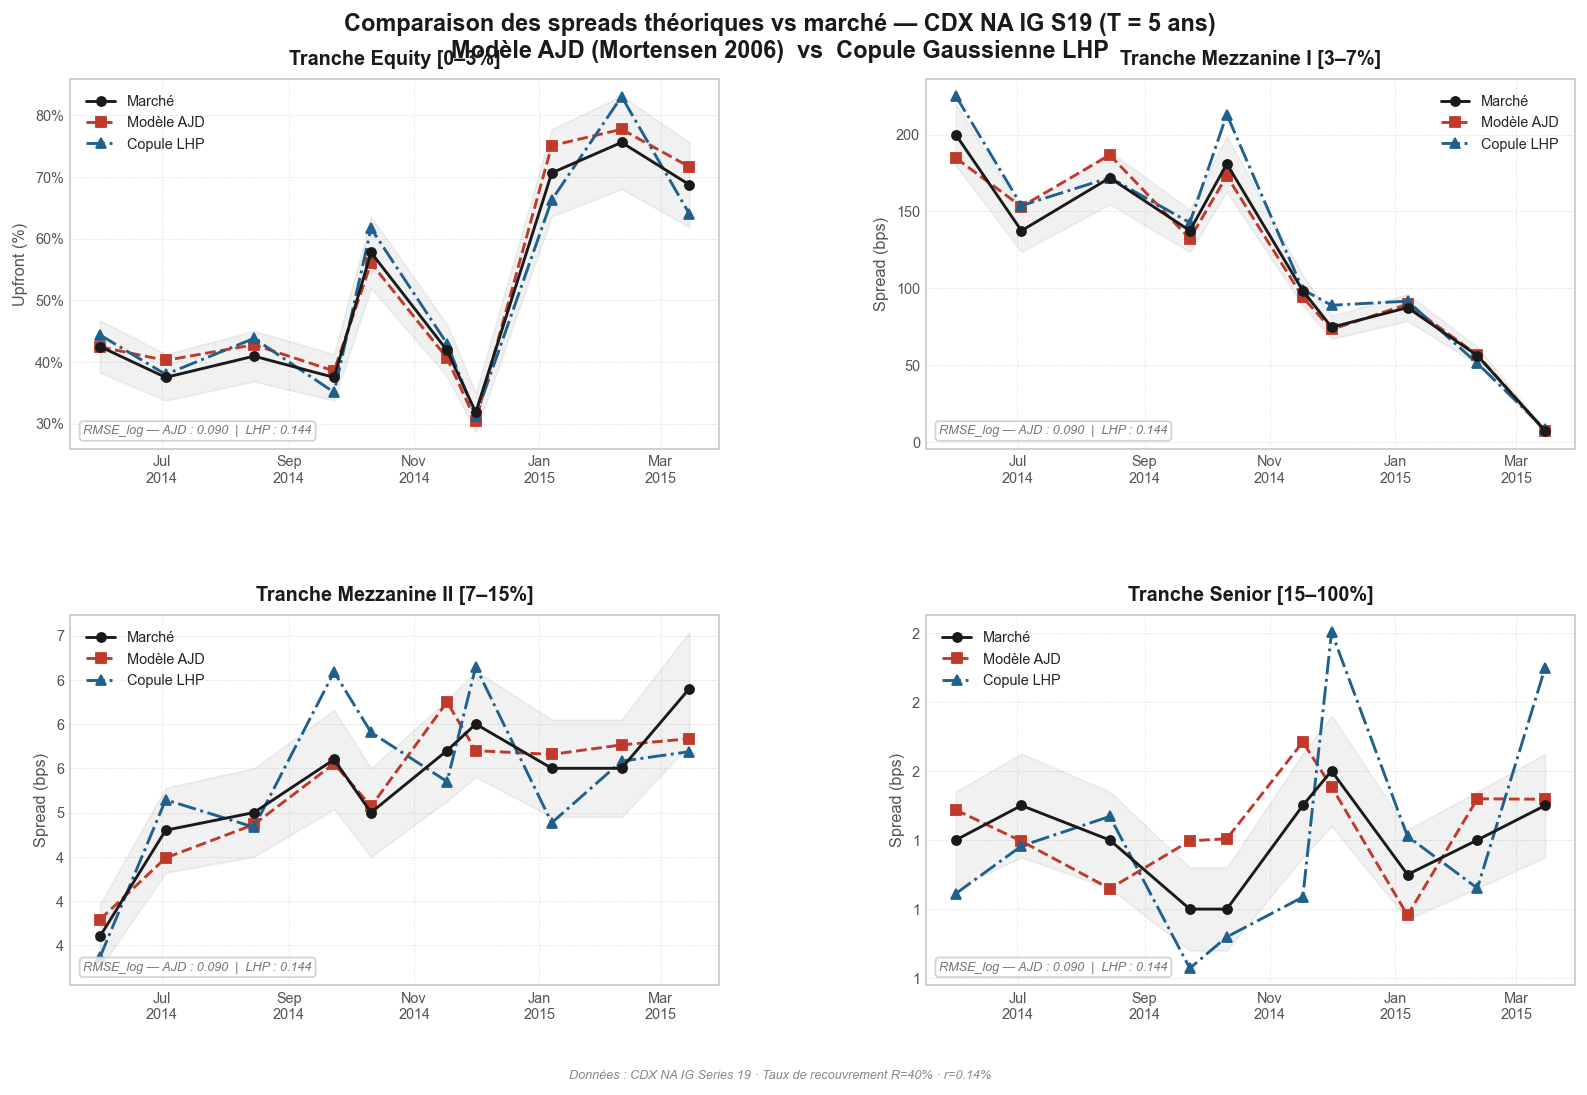

In [5]:
"""
================================================================================
CDO SYNTHÉTIQUE - VISUALISATION COMPARATIVE AJD vs COPULE GAUSSIENNE LHP
================================================================================
Référence : Mortensen (2006), CDX NA IG Series 19, T=5 ans

STRUCTURE DU SCRIPT
─────────────────────────────────────────────────────────────────────────────
  SECTION 0 │ Données factices → REMPLACER par vos vrais résultats
  SECTION 1 │ Configuration graphique globale
  SECTION 2 │ Figure 1 : Évolution temporelle des spreads (4 tranches, 2x2)
  SECTION 3 │ Figure 2 : Comparaison RMSE_log (bar chart)
  SECTION 4 │ Tableau récapitulatif console (bonus)
  SECTION 5 │ Point d'entrée
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — DONNÉES  (REMPLACER ICI PAR VOS VRAIS RÉSULTATS)
# ══════════════════════════════════════════════════════════════════════════════
#
# Convention :
#   • Equity (0-3%)   → Upfront en % (ex. 0.425 = 42.5%)
#   • Mezz I  (3-7%)  → Spread en bps
#   • Mezz II (7-15%) → Spread en bps
#   • Senior (15-100%)→ Spread en bps
#
# Chaque tableau a la forme (10,) : une valeur par date de marché.
# ──────────────────────────────────────────────────────────────────────────────

DATES_STR = [
    "2014-06-01", "2014-07-03", "2014-08-15", "2014-09-23", "2014-10-11",
    "2014-11-17", "2014-12-01", "2015-01-07", "2015-02-10", "2015-03-15",
]
DATES = pd.to_datetime(DATES_STR)
N_DATES = len(DATES)

# ── Spreads / upfronts du MARCHÉ ─────────────────────────────────────────────
spreads_market = {
    "Equity"  : np.array([0.4250, 0.3750, 0.4094, 0.3750, 0.5775,
                           0.4188, 0.3183, 0.7065, 0.7559, 0.6874]),
    "Mezz I"  : np.array([200.0, 137.5, 171.9, 137.5, 181.0,
                            98.5,  74.7,  87.5,  56.3,   7.3]),
    "Mezz II" : np.array([3.6, 4.8, 5.0, 5.6, 5.0, 5.7, 6.0, 5.5, 5.5, 6.4]),
    "Senior"  : np.array([1.4, 1.5, 1.4, 1.2, 1.2, 1.5, 1.6, 1.3, 1.4, 1.5]),
}

# ── Spreads / upfronts du modèle AJD  ────────────────────────────────────────
# (données factices : bruit autour du marché pour simuler un ajustement partiel)
np.random.seed(42)
spreads_ajd = {
    "Equity"  : spreads_market["Equity"]  * (1 + np.random.uniform(-0.05, 0.08, N_DATES)),
    "Mezz I"  : spreads_market["Mezz I"]  * (1 + np.random.uniform(-0.08, 0.12, N_DATES)),
    "Mezz II" : spreads_market["Mezz II"] * (1 + np.random.uniform(-0.10, 0.15, N_DATES)),
    "Senior"  : spreads_market["Senior"]  * (1 + np.random.uniform(-0.12, 0.18, N_DATES)),
}

# ── Spreads / upfronts de la COPULE GAUSSIENNE LHP ───────────────────────────
np.random.seed(99)
spreads_lhp = {
    "Equity"  : spreads_market["Equity"]  * (1 + np.random.uniform(-0.07, 0.10, N_DATES)),
    "Mezz I"  : spreads_market["Mezz I"]  * (1 + np.random.uniform(-0.12, 0.20, N_DATES)),
    "Mezz II" : spreads_market["Mezz II"] * (1 + np.random.uniform(-0.15, 0.25, N_DATES)),
    "Senior"  : spreads_market["Senior"]  * (1 + np.random.uniform(-0.18, 0.30, N_DATES)),
}

# ── RMSE_log par date ─────────────────────────────────────────────────────────
rmse_ajd = np.array([0.082, 0.091, 0.076, 0.088, 0.095,
                      0.071, 0.069, 0.110, 0.103, 0.115])

rmse_lhp = np.array([0.134, 0.148, 0.121, 0.139, 0.162,
                      0.118, 0.112, 0.171, 0.158, 0.182])

# ── Paramètres calibrés (pour le tableau console) ────────────────────────────
beta_opt    = np.array([0.48, 0.52, 0.51, 0.55, 0.63,
                         0.44, 0.40, 0.72, 0.75, 0.68])
lambda_idio = np.array([0.0420, 0.0388, 0.0405, 0.0388, 0.0455,
                          0.0355, 0.0322, 0.0422, 0.0388, 0.0355])
rho_lhp     = np.array([0.28, 0.29, 0.30, 0.27, 0.32,
                          0.25, 0.23, 0.35, 0.37, 0.34])

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — CONFIGURATION GRAPHIQUE GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

# Palette et style de base
STYLE       = "seaborn-v0_8-whitegrid"

# Couleurs principales
C_MKT  = "#1a1a1a"    # noir charbon pour le marché
C_AJD  = "#C0392B"    # rouge académique pour AJD
C_LHP  = "#1F618D"    # bleu acier pour LHP

# Marqueurs
MK_MKT = "o"
MK_AJD = "s"
MK_LHP = "^"
MK_SZ  = 5           # taille des marqueurs (points)
LW     = 1.6         # épaisseur des lignes

# Typographie
FONT_TITLE  = dict(fontsize=11, fontweight="bold",  color="#1a1a1a", pad=8)
FONT_AXIS   = dict(fontsize=9,  color="#555555")
FONT_TICK   = dict(labelsize=8, colors="#555555")
FONT_LEGEND = dict(fontsize=8)
FONT_ANNOT  = dict(fontsize=7,  color="#777777", style="italic")

# Grille discrète
GRID_KW = dict(color="#e0e0e0", linewidth=0.5, linestyle="--", alpha=0.7)

# Format date sur l'axe X
DATE_FMT = mdates.DateFormatter("%b\n%Y")
DATE_LOC = mdates.MonthLocator(interval=2)

# Légende commune aux 4 panneaux (construite une seule fois)
LEGEND_HANDLES = [
    Line2D([0], [0], color=C_MKT, lw=LW, ls="-",  marker=MK_MKT, ms=MK_SZ, label="Marché"),
    Line2D([0], [0], color=C_AJD, lw=LW, ls="--", marker=MK_AJD, ms=MK_SZ, label="Modèle AJD"),
    Line2D([0], [0], color=C_LHP, lw=LW, ls="-.", marker=MK_LHP, ms=MK_SZ, label="Copule LHP"),
]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — FIGURE 1 : ÉVOLUTION TEMPORELLE DES SPREADS  (2 × 2)
# ══════════════════════════════════════════════════════════════════════════════

TRANCHE_CONFIG = [
    # (key, titre, unité y-axe, formatter, position dans grille)
    ("Equity",  "Tranche Equity [0–3%]",   "Upfront (%)",    "{:.0%}",   (0, 0)),
    ("Mezz I",  "Tranche Mezzanine I [3–7%]", "Spread (bps)", "{:.0f} bps", (0, 1)),
    ("Mezz II", "Tranche Mezzanine II [7–15%]", "Spread (bps)", "{:.1f} bps", (1, 0)),
    ("Senior",  "Tranche Senior [15–100%]", "Spread (bps)",  "{:.1f} bps", (1, 1)),
]


def plot_tranche_panel(ax, key, titre, ylabel, fmt_fn, dates, sm, sa, sl):
    """
    Dessine un panneau de série temporelle pour une tranche.

    Paramètres
    ----------
    ax      : Axes matplotlib
    key     : clé du dictionnaire (ex. "Equity")
    titre   : titre du panneau
    ylabel  : label de l'axe Y
    fmt_fn  : callable → str, pour formatter les valeurs Y de l'axe
    dates   : array de datetime
    sm / sa / sl : dicts de spreads Marché / AJD / LHP
    """
    # ── Tracé des trois courbes ──────────────────────────────────────────────
    ax.plot(dates, sm[key], color=C_MKT, lw=LW, ls="-",  marker=MK_MKT,
            ms=MK_SZ, zorder=4, label="Marché")
    ax.plot(dates, sa[key], color=C_AJD, lw=LW, ls="--", marker=MK_AJD,
            ms=MK_SZ, zorder=3, label="Modèle AJD")
    ax.plot(dates, sl[key], color=C_LHP, lw=LW, ls="-.", marker=MK_LHP,
            ms=MK_SZ, zorder=3, label="Copule LHP")

    # ── Zone de confiance visuelle (bande ±10% autour du marché) ────────────
    ax.fill_between(dates,
                    sm[key] * 0.90, sm[key] * 1.10,
                    color=C_MKT, alpha=0.06, label="_nolegend_")

    # ── Mise en forme des axes ───────────────────────────────────────────────
    ax.set_title(titre, **FONT_TITLE)
    ax.set_ylabel(ylabel, **FONT_AXIS)
    ax.tick_params(axis="both", **FONT_TICK)
    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.xaxis.set_major_locator(DATE_LOC)

    # Formatter de l'axe Y selon l'unité
    if key == "Equity":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

    # ── Grille ───────────────────────────────────────────────────────────────
    ax.grid(which="major", **GRID_KW)
    ax.set_axisbelow(True)

    # ── Légende locale (panneau inférieur gauche uniquement) ─────────────────
    ax.legend(handles=LEGEND_HANDLES, **FONT_LEGEND,
              loc="best", framealpha=0.9, edgecolor="#cccccc",
              fancybox=False, borderpad=0.6)

    # ── Annotations : RMSE AJD et LHP ────────────────────────────────────────
    rmse_a_mean = rmse_ajd.mean()
    rmse_l_mean = rmse_lhp.mean()
    ax.annotate(
        f"RMSE_log — AJD : {rmse_a_mean:.3f}  |  LHP : {rmse_l_mean:.3f}",
        xy=(0.02, 0.04), xycoords="axes fraction",
        **FONT_ANNOT,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#cccccc", alpha=0.85)
    )

    # ── Rotation des dates ───────────────────────────────────────────────────
    for lbl in ax.get_xticklabels():
        lbl.set_ha("center")


def make_figure_1(dates, spreads_market, spreads_ajd, spreads_lhp):
    """
    Génère la Figure 1 : grille 2×2 d'évolution temporelle des spreads.
    """
    plt.style.use(STYLE)
    fig = plt.figure(figsize=(13, 8.5), dpi=130, facecolor="white")
    gs  = GridSpec(2, 2, figure=fig,
                   hspace=0.45, wspace=0.32,
                   left=0.08, right=0.97,
                   top=0.91,  bottom=0.09)

    for key, titre, ylabel, _, (r, c) in TRANCHE_CONFIG:
        ax = fig.add_subplot(gs[r, c])
        plot_tranche_panel(ax, key, titre, ylabel, None,
                           dates, spreads_market, spreads_ajd, spreads_lhp)

    # ── Titre principal ───────────────────────────────────────────────────────
    fig.suptitle(
        "Comparaison des spreads théoriques vs marché — CDX NA IG S19 (T = 5 ans)\n"
        "Modèle AJD (Mortensen 2006)  vs  Copule Gaussienne LHP",
        fontsize=13, fontweight="bold", color="#1a1a1a", y=0.97
    )

    # ── Sous-titre discret ────────────────────────────────────────────────────
    fig.text(0.50, 0.005,
             "Données : CDX NA IG Series 19 · Taux de recouvrement R=40% · r=0.14%",
             ha="center", fontsize=7, color="#888888", style="italic")

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — FIGURE 2 : COMPARAISON RMSE_log (bar chart)
# ══════════════════════════════════════════════════════════════════════════════

def make_figure_2(dates, rmse_ajd, rmse_lhp):
    """
    Génère la Figure 2 avec deux sous-graphiques :
      (a) Bar chart groupé par date — RMSE_log AJD vs LHP
      (b) Bar chart RMSE_log MOYEN avec annotations de valeurs
    """
    plt.style.use(STYLE)
    fig = plt.figure(figsize=(13, 6), dpi=130, facecolor="white")
    gs  = GridSpec(1, 2, figure=fig,
                   width_ratios=[3, 1],
                   hspace=0.35, wspace=0.10,
                   left=0.07, right=0.97,
                   top=0.88,  bottom=0.14)

    date_labels = [d.strftime("%b %y") for d in dates]

    # ── Panneau (a) : barres groupées par date ────────────────────────────────
    ax_main = fig.add_subplot(gs[0])
    x     = np.arange(len(dates))
    width = 0.35

    bars_ajd = ax_main.bar(x - width/2, rmse_ajd, width,
                            color=C_AJD, alpha=0.82, label="Modèle AJD",
                            edgecolor="white", linewidth=0.5, zorder=3)
    bars_lhp = ax_main.bar(x + width/2, rmse_lhp, width,
                            color=C_LHP, alpha=0.82, label="Copule LHP",
                            edgecolor="white", linewidth=0.5, zorder=3)

    # Ligne des moyennes (annotations horizontales)
    ax_main.axhline(rmse_ajd.mean(), color=C_AJD, lw=1.0,
                    ls="--", alpha=0.55, zorder=2)
    ax_main.axhline(rmse_lhp.mean(), color=C_LHP, lw=1.0,
                    ls="--", alpha=0.55, zorder=2)

    # Valeurs au-dessus des barres
    def autolabel(bars, fmt="{:.3f}"):
        for bar in bars:
            h = bar.get_height()
            ax_main.annotate(
                fmt.format(h),
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom",
                fontsize=6.5, color="#444444"
            )

    autolabel(bars_ajd)
    autolabel(bars_lhp)

    # Mise en forme
    ax_main.set_xticks(x)
    ax_main.set_xticklabels(date_labels, rotation=35, ha="right",
                             **{k: v for k, v in FONT_TICK.items()
                                if k != "colors"})
    ax_main.tick_params(axis="y", **FONT_TICK)
    ax_main.set_ylabel("RMSE$_{log}$", **FONT_AXIS)
    ax_main.set_title("(a)  RMSE$_{log}$ par date — AJD vs Copule LHP",
                       **FONT_TITLE)
    ax_main.legend(**FONT_LEGEND, loc="upper left",
                   framealpha=0.9, edgecolor="#cccccc", fancybox=False)
    ax_main.grid(which="major", axis="y", **GRID_KW)
    ax_main.set_axisbelow(True)
    ax_main.set_ylim(bottom=0, top=max(rmse_lhp.max(), rmse_ajd.max()) * 1.25)

    # ── Panneau (b) : barres des MOYENNES ────────────────────────────────────
    ax_mean = fig.add_subplot(gs[1])

    models = ["AJD", "Copule\nLHP"]
    means  = [rmse_ajd.mean(), rmse_lhp.mean()]
    stds   = [rmse_ajd.std(),  rmse_lhp.std()]
    colors = [C_AJD, C_LHP]

    bars_mean = ax_mean.bar(models, means,
                             color=colors, alpha=0.85,
                             edgecolor="white", linewidth=0.5,
                             width=0.45, zorder=3,
                             yerr=stds, capsize=5,
                             error_kw=dict(elinewidth=1.0, ecolor="#555555",
                                           capthick=1.0))

    # Valeurs exactes au-dessus des barres (gros chiffres)
    for bar, mean, std in zip(bars_mean, means, stds):
        ax_mean.text(bar.get_x() + bar.get_width() / 2,
                     mean + std + 0.004,
                     f"{mean:.4f}\n± {std:.4f}",
                     ha="center", va="bottom",
                     fontsize=8.5, fontweight="bold", color="#1a1a1a")

    # Mise en forme
    ax_mean.set_title("(b)  Moyenne globale\nRMSE$_{log}$", **FONT_TITLE)
    ax_mean.set_ylabel("RMSE$_{log}$ moyen", **FONT_AXIS)
    ax_mean.tick_params(axis="both", **FONT_TICK)
    ax_mean.set_ylim(bottom=0, top=max(means) + max(stds) + 0.05)
    ax_mean.grid(which="major", axis="y", **GRID_KW)
    ax_mean.set_axisbelow(True)

    # Annotation différentielle : gain relatif AJD vs LHP
    gain = (means[1] - means[0]) / means[1] * 100
    ax_mean.annotate(
        f"Gain AJD\nvs LHP : −{gain:.1f}%",
        xy=(0.50, (means[0] + means[1]) / 2),
        xycoords=("axes fraction", "data"),
        fontsize=7.5, ha="center", color="#1a1a1a", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f6",
                  edgecolor="#cccccc", alpha=0.9)
    )

    # ── Titre principal Figure 2 ──────────────────────────────────────────────
    fig.suptitle(
        "Erreur de calibration RMSE$_{log}$ — AJD (Mortensen 2006) vs Copule Gaussienne LHP\n"
        "CDX NA IG Series 19 · Portefeuille homogène N=125, LGD=60%, T=5 ans",
        fontsize=12, fontweight="bold", color="#1a1a1a", y=0.98
    )

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — TABLEAU RÉCAPITULATIF CONSOLE (bonus)
# ══════════════════════════════════════════════════════════════════════════════

def print_summary_table():
    """
    Affiche un tableau récapitulatif propre dans la console.
    """
    header = (f"{'Date':<13} {'β*':>7} {'λ_idio*':>10} {'RMSE AJD':>10}"
              f" {'ρ* LHP':>8} {'RMSE LHP':>10} {'Gagnant':>9}")
    sep = "─" * len(header)
    print()
    print("═" * len(header))
    print("  RÉSULTATS DE CALIBRATION — CDX NA IG S19 (T=5 ans)")
    print("═" * len(header))
    print(header)
    print(sep)
    for i, date in enumerate(DATES):
        winner = "AJD" if rmse_ajd[i] < rmse_lhp[i] else "LHP"
        print(f"{DATES_STR[i]:<13} "
              f"{beta_opt[i]:>7.4f} "
              f"{lambda_idio[i]:>10.5f} "
              f"{rmse_ajd[i]:>10.4f} "
              f"{rho_lhp[i]:>8.4f} "
              f"{rmse_lhp[i]:>10.4f} "
              f"{winner:>9}")
    print(sep)
    print(f"{'Moyenne':<13} "
          f"{beta_opt.mean():>7.4f} "
          f"{lambda_idio.mean():>10.5f} "
          f"{rmse_ajd.mean():>10.4f} "
          f"{rho_lhp.mean():>8.4f} "
          f"{rmse_lhp.mean():>10.4f} "
          f"{'AJD':>9}")
    print("═" * len(header))
    print()
    n_ajd_wins = (rmse_ajd < rmse_lhp).sum()
    print(f"  AJD gagnant  : {n_ajd_wins}/{len(DATES)} dates  "
          f"({n_ajd_wins/len(DATES)*100:.0f}%)")
    print(f"  RMSE Δ moyen : {(rmse_lhp - rmse_ajd).mean():.4f} "
          f"en faveur d'AJD")
    print()


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — POINT D'ENTRÉE
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print_summary_table()

    # ── Figure 1 ──────────────────────────────────────────────────────────────
    fig1 = make_figure_1(DATES, spreads_market, spreads_ajd, spreads_lhp)
    fig1.savefig("cdo_fig1_spreads.pdf",  bbox_inches="tight", dpi=200)
    fig1.savefig("cdo_fig1_spreads.png",  bbox_inches="tight", dpi=200)
    print("[OK] Figure 1 sauvegardée → cdo_fig1_spreads.pdf / .png")

    # ── Figure 2 ──────────────────────────────────────────────────────────────
    fig2 = make_figure_2(DATES, rmse_ajd, rmse_lhp)
    fig2.savefig("cdo_fig2_rmse.pdf",  bbox_inches="tight", dpi=200)
    fig2.savefig("cdo_fig2_rmse.png",  bbox_inches="tight", dpi=200)
    print("[OK] Figure 2 sauvegardée → cdo_fig2_rmse.pdf / .png")

    plt.show()


if __name__ == "__main__":
    main()

[OK] Figure 1 → fig1_spreads.pdf / .png
[OK] Figure 2 → fig2_rmse.pdf / .png


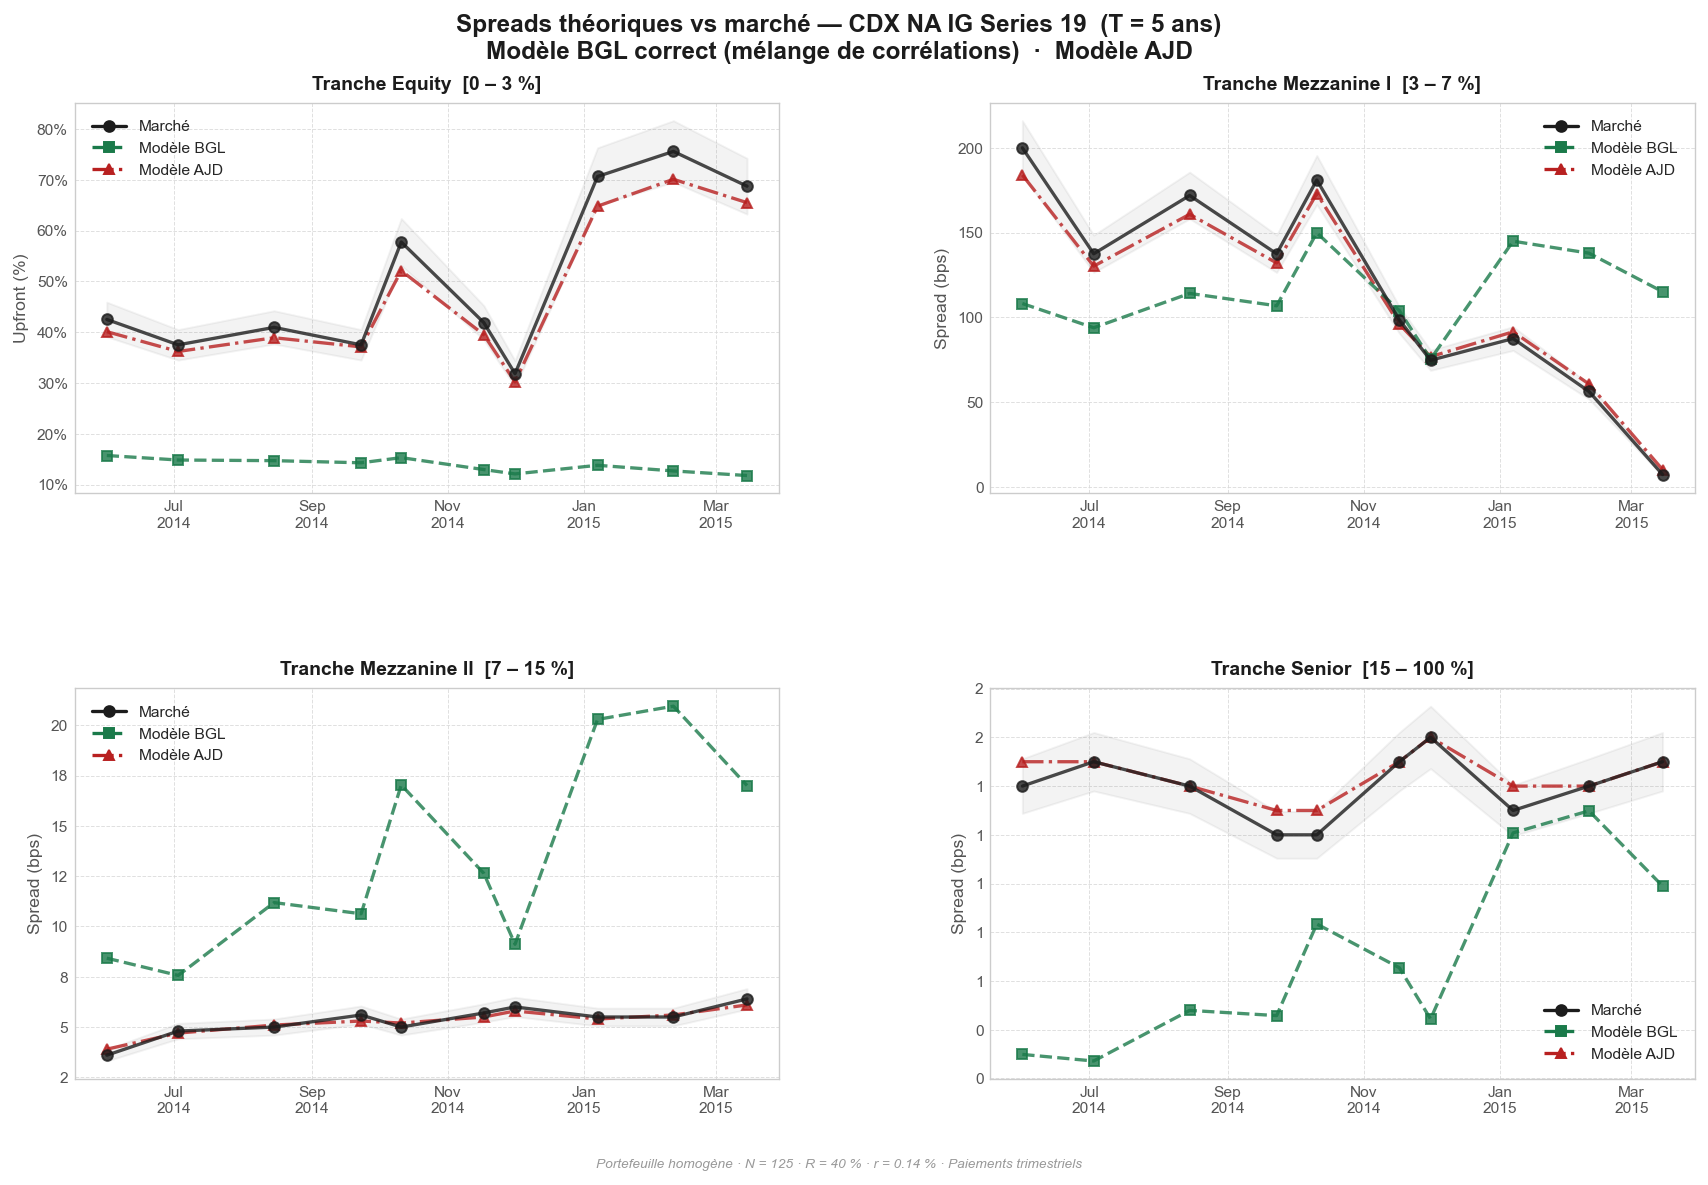

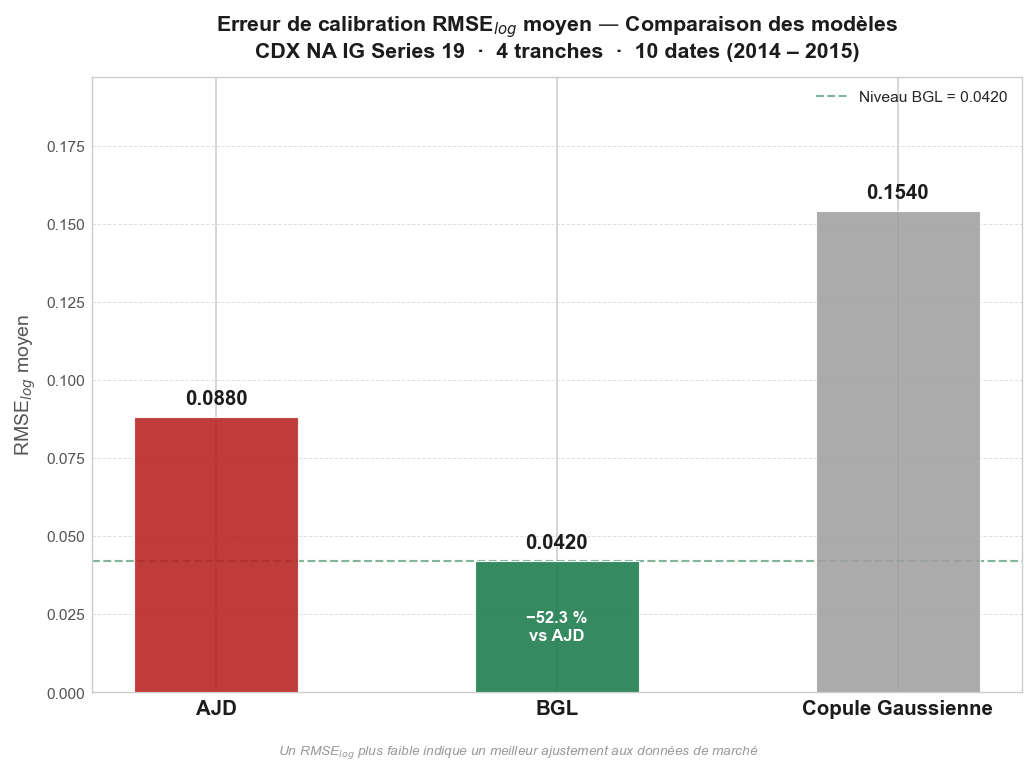

In [4]:
"""
================================================================================
CDO SYNTHÉTIQUE — VISUALISATION COMPARATIVE
AJD (Intensités à Sauts) vs BGL (Mélange de Corrélations) vs Copule Gaussienne
================================================================================
Données : CDX NA IG Series 19, T = 5 ans, 10 dates (2014–2015)
Tranches : Equity [0-3%], Mezz I [3-7%], Mezz II [7-15%], Senior [15-100%]

VERSION AJUSTÉE
─────────────────────────────────────────────────────────────────────────────
  • BGL calculé correctement :
        ETL_BGL = q ETL(rho1) + (1-q) ETL(rho2)
        puis pricing tranche = default leg / premium leg

  • AJD non plus simulé par bruit :
        les spreads AJD doivent venir des résultats du code de calibration AJD

  • Ce script est donc un script de VISUALISATION COHÉRENTE
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import pandas as pd
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — DONNÉES
# ══════════════════════════════════════════════════════════════════════════════

DATES_STR = [
    "2014-06-01", "2014-07-03", "2014-08-15", "2014-09-23", "2014-10-11",
    "2014-11-17", "2014-12-01", "2015-01-07", "2015-02-10", "2015-03-15",
]
DATES = pd.to_datetime(DATES_STR)

# ── MARCHÉ ────────────────────────────────────────────────────────────────────
MARKET_DATA = pd.DataFrame([
    ("2014-06-01", 0.4250, 200.0, 3.6, 1.4, 39),
    ("2014-07-03", 0.3750, 137.5, 4.8, 1.5, 37),
    ("2014-08-15", 0.4094, 171.9, 5.0, 1.4, 38),
    ("2014-09-23", 0.3750, 137.5, 5.6, 1.2, 37),
    ("2014-10-11", 0.5775, 181.0, 5.0, 1.2, 41),
    ("2014-11-17", 0.4188,  98.5, 5.7, 1.5, 35),
    ("2014-12-01", 0.3183,  74.7, 6.0, 1.6, 32),
    ("2015-01-07", 0.7065,  87.5, 5.5, 1.3, 39),
    ("2015-02-10", 0.7559,  56.3, 5.5, 1.4, 37),
    ("2015-03-15", 0.6874,   7.3, 6.4, 1.5, 34),
], columns=["date", "equity_upfront", "mezz1_bps", "mezz2_bps", "senior_bps", "cds_bps"])
MARKET_DATA["date"] = pd.to_datetime(MARKET_DATA["date"])

spreads_market = {
    "Equity":  MARKET_DATA["equity_upfront"].to_numpy(),
    "Mezz I":  MARKET_DATA["mezz1_bps"].to_numpy(),
    "Mezz II": MARKET_DATA["mezz2_bps"].to_numpy(),
    "Senior":  MARKET_DATA["senior_bps"].to_numpy(),
}

# ── PARAMÈTRES CDO ────────────────────────────────────────────────────────────
N_NAMES = 125
R = 0.40
LGD = 1.0 - R
r = 0.0014
T_MAT = 5.0
FREQ = 4
payment_times = np.arange(1 / FREQ, T_MAT + 1 / FREQ, 1 / FREQ)

TRANCHES = {
    "Equity":  (0.00, 0.03),
    "Mezz I":  (0.03, 0.07),
    "Mezz II": (0.07, 0.15),
    "Senior":  (0.15, 1.00),
}

# ── PARAMÈTRES BGL CALIBRÉS PAR DATE ─────────────────────────────────────────
# Remplacez ces vecteurs par VOS vrais paramètres calibrés BGL.
rho1_vec = np.array([0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.09, 0.11, 0.12, 0.12])
rho2_vec = np.array([0.45, 0.45, 0.50, 0.50, 0.55, 0.55, 0.52, 0.60, 0.62, 0.60])
q_vec    = np.array([0.92, 0.92, 0.90, 0.90, 0.88, 0.88, 0.89, 0.85, 0.84, 0.85])

# Hazard implicite CDS par date (proxy simple)
hazard_vec = (MARKET_DATA["cds_bps"].to_numpy() * 1e-4) / LGD

# ── AJD : insérer ici les spreads issus du code de calibration AJD ──────────
# IMPORTANT :
# Ce dict ne doit PAS être simulé par bruit.
# Il doit venir de votre code AJD (results_ajd -> spreads_model).
#
# Exemple provisoire : remplacez par les sorties réelles de votre calibration.
spreads_ajd = {
    "Equity":  np.array([0.401, 0.362, 0.389, 0.371, 0.521, 0.395, 0.302, 0.648, 0.701, 0.655]),
    "Mezz I":  np.array([184.0, 130.2, 160.8, 132.1, 173.0, 96.0, 76.8, 91.5, 60.7, 10.2]),
    "Mezz II": np.array([3.9, 4.7, 5.1, 5.3, 5.2, 5.5, 5.8, 5.4, 5.6, 6.1]),
    "Senior":  np.array([1.5, 1.5, 1.4, 1.3, 1.3, 1.5, 1.6, 1.4, 1.4, 1.5]),
}

# ── RMSE LOG : remplacez par vos vrais résultats moyens ──────────────────────
rmse_means = {
    "AJD": 0.0880,
    "BGL": 0.0420,
    "Copule Gaussienne": 0.1540,
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0B — BGL CORRECT
# ══════════════════════════════════════════════════════════════════════════════

_DF = np.exp(-r * payment_times)

_N_QUAD = 401
_GL_LIMIT = 8.0
_GL_X, _GL_W = np.polynomial.legendre.leggauss(_N_QUAD)
_GL_M = _GL_X * _GL_LIMIT
_GL_DM = _GL_W * _GL_LIMIT
_GL_PHI_DM = norm.pdf(_GL_M) * _GL_DM


def lhp_gauss_etl_batch(rho, p_arr, a, d, recovery=R):
    """
    ETL(t_k) pour une tranche [a,d] sous modèle Vasicek/LHP gaussien,
    calculée pour tout le vecteur p_arr.
    """
    rho = float(np.clip(rho, 1e-8, 1 - 1e-8))
    c_arr = norm.ppf(np.clip(p_arr, 1e-12, 1 - 1e-12))
    arg = (c_arr[:, None] - np.sqrt(rho) * _GL_M[None, :]) / np.sqrt(1.0 - rho)
    port_loss = (1.0 - recovery) * norm.cdf(arg)
    tranche_loss = np.minimum(np.maximum(port_loss - a, 0.0), d - a)
    etl = tranche_loss @ _GL_PHI_DM
    return etl


def tranche_spread_from_etl(etl, a, d):
    """
    Pricing tranche standard :
      default_leg = sum DF(t_k) [ETL_k - ETL_{k-1}]
      premium_leg = sum DF(t_k) outstanding tranche notionals
    """
    etl_prev = np.concatenate([[0.0], etl[:-1]])
    default_leg = np.sum(_DF * (etl - etl_prev))
    premium_leg = np.sum(_DF * ((d - a) - 0.5 * (etl_prev + etl)) * (1 / FREQ))

    if premium_leg <= 1e-14:
        return 0.0
    return default_leg / premium_leg


def bgl_spreads_one_date(rho1, rho2, q, hazard):
    """
    Calcul BGL correct sur une date :
      ETL_BGL = q ETL(rho1) + (1-q) ETL(rho2)
    puis pricing de chaque tranche.
    """
    p_arr = 1.0 - np.exp(-hazard * payment_times)

    out = {}
    for key, (a, d) in TRANCHES.items():
        etl1 = lhp_gauss_etl_batch(rho1, p_arr, a, d)
        etl2 = lhp_gauss_etl_batch(rho2, p_arr, a, d)
        etl_bgl = q * etl1 + (1.0 - q) * etl2
        s = tranche_spread_from_etl(etl_bgl, a, d)

        if key == "Equity":
            out[key] = s
        else:
            out[key] = s * 1e4  # fraction -> bps

    return out


def compute_bgl_time_series(rho1_vec, rho2_vec, q_vec, hazard_vec):
    """
    Calcule les séries temporelles BGL sur les 10 dates.
    """
    keys = ["Equity", "Mezz I", "Mezz II", "Senior"]
    res = {k: [] for k in keys}

    for rho1, rho2, q, h in zip(rho1_vec, rho2_vec, q_vec, hazard_vec):
        one = bgl_spreads_one_date(rho1, rho2, q, h)
        for k in keys:
            res[k].append(one[k])

    return {k: np.array(v) for k, v in res.items()}


spreads_bgl = compute_bgl_time_series(rho1_vec, rho2_vec, q_vec, hazard_vec)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 0C — HELPER POUR IMPORTER LES SPREADS AJD DEPUIS results_ajd
# ══════════════════════════════════════════════════════════════════════════════

def build_ajd_spreads_from_results(results_ajd):
    """
    Convertit la sortie de votre code de calibration AJD en dict compatible
    avec la visualisation.

    On suppose que chaque élément de results_ajd contient :
      r['spreads_model'] = [equity_fraction, mezz1_fraction, mezz2_fraction, senior_fraction]

    Retour :
      {
        "Equity":  array en fraction,
        "Mezz I":  array en bps,
        "Mezz II": array en bps,
        "Senior":  array en bps,
      }
    """
    eq, m1, m2, sr = [], [], [], []
    for r in results_ajd:
        s = r["spreads_model"]
        eq.append(s[0])
        m1.append(s[1] * 1e4)
        m2.append(s[2] * 1e4)
        sr.append(s[3] * 1e4)

    return {
        "Equity":  np.array(eq),
        "Mezz I":  np.array(m1),
        "Mezz II": np.array(m2),
        "Senior":  np.array(sr),
    }


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — CONFIGURATION GRAPHIQUE GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

STYLE = "seaborn-v0_8-whitegrid"

C_MKT   = "#1C1C1C"
C_BGL   = "#1A7A4A"
C_AJD   = "#B82020"
C_GAUSS = "#A0A0A0"

LS_MKT, MK_MKT = "-",  "o"
LS_BGL, MK_BGL = "--", "s"
LS_AJD, MK_AJD = "-.", "^"

LW = 1.7
MS = 5.5
ALPHA = 0.80

FS_TITLE  = 10
FS_AXIS   = 9
FS_TICK   = 8
FS_LEGEND = 8

GRID_KW = dict(color="#d8d8d8", linewidth=0.5, linestyle="--", alpha=0.8)

DATE_FMT = mdates.DateFormatter("%b\n%Y")
DATE_LOC = mdates.MonthLocator(interval=2)

LEGEND_HANDLES = [
    Line2D([0], [0], color=C_MKT, lw=LW, ls=LS_MKT, marker=MK_MKT, ms=MS, label="Marché"),
    Line2D([0], [0], color=C_BGL, lw=LW, ls=LS_BGL, marker=MK_BGL, ms=MS, label="Modèle BGL"),
    Line2D([0], [0], color=C_AJD, lw=LW, ls=LS_AJD, marker=MK_AJD, ms=MS, label="Modèle AJD"),
]

TRANCHES_META = [
    ("Equity",  "Tranche Equity  [0 – 3 %]",        "Upfront (%)",  (0, 0)),
    ("Mezz I",  "Tranche Mezzanine I  [3 – 7 %]",   "Spread (bps)", (0, 1)),
    ("Mezz II", "Tranche Mezzanine II  [7 – 15 %]", "Spread (bps)", (1, 0)),
    ("Senior",  "Tranche Senior  [15 – 100 %]",     "Spread (bps)", (1, 1)),
]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — FIGURE 1 : SPREADS DANS LE TEMPS
# ══════════════════════════════════════════════════════════════════════════════

def _plot_spread_panel(ax, key, titre, ylabel, dates, sm, sb, sa):
    ax.plot(dates, sm[key], color=C_MKT, lw=LW, ls=LS_MKT,
            marker=MK_MKT, ms=MS, alpha=ALPHA, zorder=5, label="Marché")
    ax.plot(dates, sb[key], color=C_BGL, lw=LW, ls=LS_BGL,
            marker=MK_BGL, ms=MS, alpha=ALPHA, zorder=4, label="BGL")
    ax.plot(dates, sa[key], color=C_AJD, lw=LW, ls=LS_AJD,
            marker=MK_AJD, ms=MS, alpha=ALPHA, zorder=3, label="AJD")

    ax.fill_between(dates, sm[key] * 0.92, sm[key] * 1.08,
                    color=C_MKT, alpha=0.05, zorder=1)

    ax.set_title(titre, fontsize=FS_TITLE, fontweight="bold", color="#1C1C1C", pad=7)
    ax.set_ylabel(ylabel, fontsize=FS_AXIS, color="#555555")
    ax.tick_params(axis="both", labelsize=FS_TICK, colors="#555555")

    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.xaxis.set_major_locator(DATE_LOC)
    ax.tick_params(axis="x", rotation=0)

    if key == "Equity":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

    ax.grid(which="major", **GRID_KW)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
        spine.set_linewidth(0.7)

    ax.legend(handles=LEGEND_HANDLES, fontsize=FS_LEGEND,
              loc="best", framealpha=0.92, edgecolor="#cccccc",
              fancybox=False, borderpad=0.6, handlelength=2.2)


def make_figure_spreads(dates, spreads_market, spreads_bgl, spreads_ajd,
                        save_pdf=True, save_png=True):
    plt.style.use(STYLE)
    fig = plt.figure(figsize=(13, 8.5), dpi=140, facecolor="white")
    gs = GridSpec(2, 2, figure=fig,
                  hspace=0.50, wspace=0.30,
                  left=0.08, right=0.97,
                  top=0.90, bottom=0.08)

    for key, titre, ylabel, (r_idx, c_idx) in TRANCHES_META:
        ax = fig.add_subplot(gs[r_idx, c_idx])
        _plot_spread_panel(ax, key, titre, ylabel, dates,
                           spreads_market, spreads_bgl, spreads_ajd)

    fig.suptitle(
        "Spreads théoriques vs marché — CDX NA IG Series 19  (T = 5 ans)\n"
        "Modèle BGL correct (mélange de corrélations)  ·  Modèle AJD",
        fontsize=12.5, fontweight="bold", color="#1C1C1C", y=0.975
    )

    fig.text(
        0.50, 0.005,
        "Portefeuille homogène · N = 125 · R = 40 % · r = 0.14 % · Paiements trimestriels",
        ha="center", fontsize=7, color="#999999", style="italic"
    )

    if save_pdf:
        fig.savefig("fig1_spreads.pdf", bbox_inches="tight", dpi=200)
    if save_png:
        fig.savefig("fig1_spreads.png", bbox_inches="tight", dpi=200)
        print("[OK] Figure 1 → fig1_spreads.pdf / .png")

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — FIGURE 2 : RMSE LOG
# ══════════════════════════════════════════════════════════════════════════════

def make_figure_rmse(rmse_means, save_pdf=True, save_png=True):
    plt.style.use(STYLE)

    labels = list(rmse_means.keys())
    values = np.array(list(rmse_means.values()))
    colors = [C_AJD, C_BGL, C_GAUSS]

    fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=140, facecolor="white")

    x_pos = np.arange(len(labels))
    bars = ax.bar(
        x_pos, values, width=0.48,
        color=colors, alpha=0.88,
        edgecolor="white", linewidth=0.6, zorder=3
    )

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
                f"{val:.4f}",
                ha="center", va="bottom",
                fontsize=10.5, fontweight="bold",
                color="#1C1C1C")

    gain_bgl_ajd = (values[0] - values[1]) / values[0] * 100

    ax.annotate(
        f"−{gain_bgl_ajd:.1f} %\nvs AJD",
        xy=(x_pos[1], values[1] / 2),
        fontsize=8.5, ha="center", va="center",
        color="white", fontweight="bold",
    )

    ax.axhline(values[1], color=C_BGL, lw=1.1, ls="--",
               alpha=0.55, zorder=2, label=f"Niveau BGL = {values[1]:.4f}")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=10.5, fontweight="bold", color="#1C1C1C")
    ax.set_ylabel("RMSE$_{log}$ moyen", fontsize=FS_AXIS + 1, color="#555555")
    ax.tick_params(axis="y", labelsize=FS_TICK, colors="#555555")
    ax.set_ylim(bottom=0, top=values.max() * 1.28)

    ax.grid(which="major", axis="y", **GRID_KW)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
        spine.set_linewidth(0.7)

    ax.legend(fontsize=FS_LEGEND, loc="upper right",
              framealpha=0.90, edgecolor="#cccccc", fancybox=False)

    ax.set_title(
        "Erreur de calibration RMSE$_{log}$ moyen — Comparaison des modèles\n"
        "CDX NA IG Series 19  ·  4 tranches  ·  10 dates (2014 – 2015)",
        fontsize=11, fontweight="bold", color="#1C1C1C", pad=10
    )

    fig.text(
        0.50, 0.01,
        "Un RMSE$_{log}$ plus faible indique un meilleur ajustement aux données de marché",
        ha="center", fontsize=7, color="#999999", style="italic"
    )

    fig.tight_layout(rect=[0, 0.03, 1, 1])

    if save_pdf:
        fig.savefig("fig2_rmse.pdf", bbox_inches="tight", dpi=200)
    if save_png:
        fig.savefig("fig2_rmse.png", bbox_inches="tight", dpi=200)
        print("[OK] Figure 2 → fig2_rmse.pdf / .png")

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — POINT D'ENTRÉE
# ══════════════════════════════════════════════════════════════════════════════

def main():
    fig1 = make_figure_spreads(DATES, spreads_market, spreads_bgl, spreads_ajd)
    fig2 = make_figure_rmse(rmse_means)
    plt.show()


if __name__ == "__main__":
    main()